**Porto Seguro’s Safe Driver Prediction**

**Introduction**

This project is based on the Porto Seguro Safe Driver Prediction competition on Kaggle. The goal is to predict the probability that an auto insurance policyholder will file a claim. Accurate prediction of such risks is crucial for the insurance industry, as it helps in setting fair premiums, managing risks, and improving customer satisfaction.

**Dataset Description**

- The dataset consists of anonymized features related to insurance policyholders.  
- Features are grouped by type, and their names indicate the nature of the variable:  
  - **ind, reg, car, calc** → Group identifiers for different feature categories.  
  - **Suffix `bin`** → Binary features.  
  - **Suffix `cat`** → Categorical features.  
  - **No suffix** → Continuous or ordinal values.  
- **Missing values**: A value of `-1` indicates that the feature was missing in the observation.  
- **Target variable**: The `target` column specifies whether the policyholder filed a claim (`1`) or not (`0`).  

**Requirements**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import roc_auc_score, classification_report

import xgboost as xgb
import lightgbm as lgb

pd.set_option('display.max_columns', 50)
sns.set_style("whitegrid")

import warnings
warnings.filterwarnings('ignore')


**Data Import**

In [ ]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

In [ ]:
train.head()

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,ps_ind_10_bin,ps_ind_11_bin,ps_ind_12_bin,ps_ind_13_bin,ps_ind_14,ps_ind_15,ps_ind_16_bin,ps_ind_17_bin,ps_ind_18_bin,ps_reg_01,ps_reg_02,ps_reg_03,ps_car_01_cat,ps_car_02_cat,...,ps_car_11,ps_car_12,ps_car_13,ps_car_14,ps_car_15,ps_calc_01,ps_calc_02,ps_calc_03,ps_calc_04,ps_calc_05,ps_calc_06,ps_calc_07,ps_calc_08,ps_calc_09,ps_calc_10,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,7,0,2,2,5,1,0,0,1,0,0,0,0,0,0,0,11,0,1,0,0.7,0.2,0.718070,10,1,...,2,0.400000,0.883679,0.370810,3.605551,0.6,0.5,0.2,3,1,10,1,10.0,1.0,5.0,9.0,1.0,5.0,8.0,0.0,1.0,1.0,0.0,0.0,1.0
1,9,0,1,1,7,0,0,0,0,1,0,0,0,0,0,0,3,0,0,1,0.8,0.4,0.766078,11,1,...,3,0.316228,0.618817,0.388716,2.449490,0.3,0.1,0.3,2,1,9,5,8.0,1.0,7.0,3.0,1.0,1.0,9.0,0.0,1.0,1.0,0.0,1.0,0.0
2,13,0,5,4,9,1,0,0,0,1,0,0,0,0,0,0,12,1,0,0,0.0,0.0,-1.000000,7,1,...,1,0.316228,0.641586,0.347275,3.316625,0.5,0.7,0.1,2,2,9,1,8.0,2.0,7.0,4.0,2.0,7.0,7.0,0.0,1.0,1.0,0.0,1.0,0.0
3,16,0,0,1,2,0,0,1,0,0,0,0,0,0,0,0,8,1,0,0,0.9,0.2,0.580948,7,1,...,1,0.374166,0.542949,0.294958,2.000000,0.6,0.9,0.1,2,4,7,1,8.0,4.0,2.0,2.0,2.0,4.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0
4,17,0,0,2,0,1,0,1,0,0,0,0,0,0,0,0,9,1,0,0,0.7,0.6,0.840759,11,1,...,3,0.316070,0.565832,0.365103,2.000000,0.4,0.6,0.0,2,2,6,3,10.0,2.0,12.0,3.0,1.0,1.0,3.0,0.0,0.0,0.0,1.0,1.0,0.0


**Exploratory Data Analysis (EDA)**

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10859 entries, 0 to 10858
Data columns (total 59 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              10859 non-null  int64  
 1   target          10859 non-null  int64  
 2   ps_ind_01       10859 non-null  int64  
 3   ps_ind_02_cat   10859 non-null  int64  
 4   ps_ind_03       10859 non-null  int64  
 5   ps_ind_04_cat   10859 non-null  int64  
 6   ps_ind_05_cat   10859 non-null  int64  
 7   ps_ind_06_bin   10859 non-null  int64  
 8   ps_ind_07_bin   10859 non-null  int64  
 9   ps_ind_08_bin   10859 non-null  int64  
 10  ps_ind_09_bin   10859 non-null  int64  
 11  ps_ind_10_bin   10859 non-null  int64  
 12  ps_ind_11_bin   10859 non-null  int64  
 13  ps_ind_12_bin   10859 non-null  int64  
 14  ps_ind_13_bin   10859 non-null  int64  
 15  ps_ind_14       10859 non-null  int64  
 16  ps_ind_15       10859 non-null  int64  
 17  ps_ind_16_bin   10859 non-null 

In [ ]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,10859.0,13803.993370,7899.067694,7.000000,6951.500000,13853.000000,20630.500000,27429.000000
target,10859.0,0.037941,0.191062,0.000000,0.000000,0.000000,0.000000,1.000000
ps_ind_01,10859.0,1.907174,1.984988,0.000000,0.000000,1.000000,3.000000,7.000000
ps_ind_02_cat,10859.0,1.354821,0.655529,-1.000000,1.000000,1.000000,2.000000,4.000000
ps_ind_03,10859.0,4.407680,2.694663,0.000000,2.000000,4.000000,6.000000,11.000000
ps_ind_04_cat,10859.0,0.418455,0.493515,-1.000000,0.000000,0.000000,1.000000,1.000000
ps_ind_05_cat,10859.0,0.417165,1.371641,-1.000000,0.000000,0.000000,0.000000,6.000000
ps_ind_06_bin,10859.0,0.395432,0.488966,0.000000,0.000000,0.000000,1.000000,1.000000
ps_ind_07_bin,10859.0,0.253154,0.434838,0.000000,0.000000,0.000000,1.000000,1.000000
ps_ind_08_bin,10859.0,0.161433,0.367947,0.000000,0.000000,0.000000,0.000000,1.000000


In [ ]:
(train == -1).sum().sort_values(ascending=False).head(10)

,0
ps_car_03_cat,7490
ps_car_05_cat,4813
ps_reg_03,1951
ps_car_14,764
ps_car_07_cat,209
ps_ind_05_cat,107
ps_car_09_cat,18
ps_ind_02_cat,1
ps_car_01_cat,1
ps_ind_04_cat,1


In [ ]:
train.shape

(10859, 59)

In [ ]:
train.sample()

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,ps_ind_10_bin,ps_ind_11_bin,ps_ind_12_bin,ps_ind_13_bin,ps_ind_14,ps_ind_15,ps_ind_16_bin,ps_ind_17_bin,ps_ind_18_bin,ps_reg_01,ps_reg_02,ps_reg_03,ps_car_01_cat,ps_car_02_cat,...,ps_car_11,ps_car_12,ps_car_13,ps_car_14,ps_car_15,ps_calc_01,ps_calc_02,ps_calc_03,ps_calc_04,ps_calc_05,ps_calc_06,ps_calc_07,ps_calc_08,ps_calc_09,ps_calc_10,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
2500,6412,0,4,1,2,0,0,0,0,1,0,0,0,0,0,0,6,0,1,0,0.7,0.5,0.689656,4,0,...,2,0.424264,1.039588,0.4,3.316625,0.7,0.7,0.7,3,1,10,2,10.0,3.0,5.0,1.0,0.0,3.0,8.0,0.0,0.0,1.0,0.0,1.0,0.0


In [ ]:
# Count missing (-1 values) and true NaNs
missing_counts = (train == -1).sum()
nan_counts = train.isna().sum()

missing_df = pd.DataFrame({
    "Missing(-1)": missing_counts,
    "NaN": nan_counts,
    "Total": missing_counts + nan_counts
}).sort_values(by="Total", ascending=False)

missing_df.head(10)


,Missing(-1),NaN,Total
ps_car_03_cat,7490,0,7490
ps_car_05_cat,4813,0,4813
ps_reg_03,1951,0,1951
ps_car_14,764,0,764
ps_car_07_cat,209,0,209
ps_ind_05_cat,107,0,107
ps_car_09_cat,18,0,18
ps_ind_02_cat,1,0,1
ps_car_01_cat,1,0,1
ps_ind_04_cat,1,0,1


**Data Visualization**

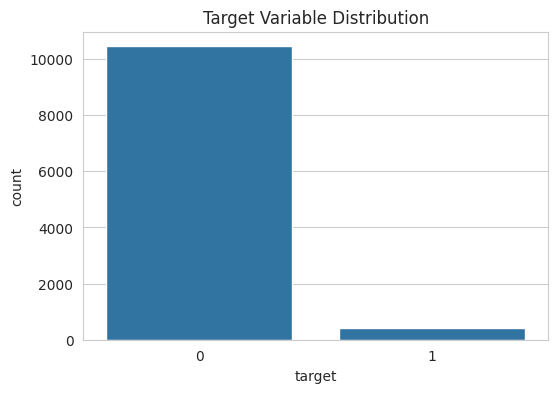

target
0    0.962059
1    0.037941
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=train)
plt.title('Target Variable Distribution')
plt.show()

print(train['target'].value_counts(normalize=True))

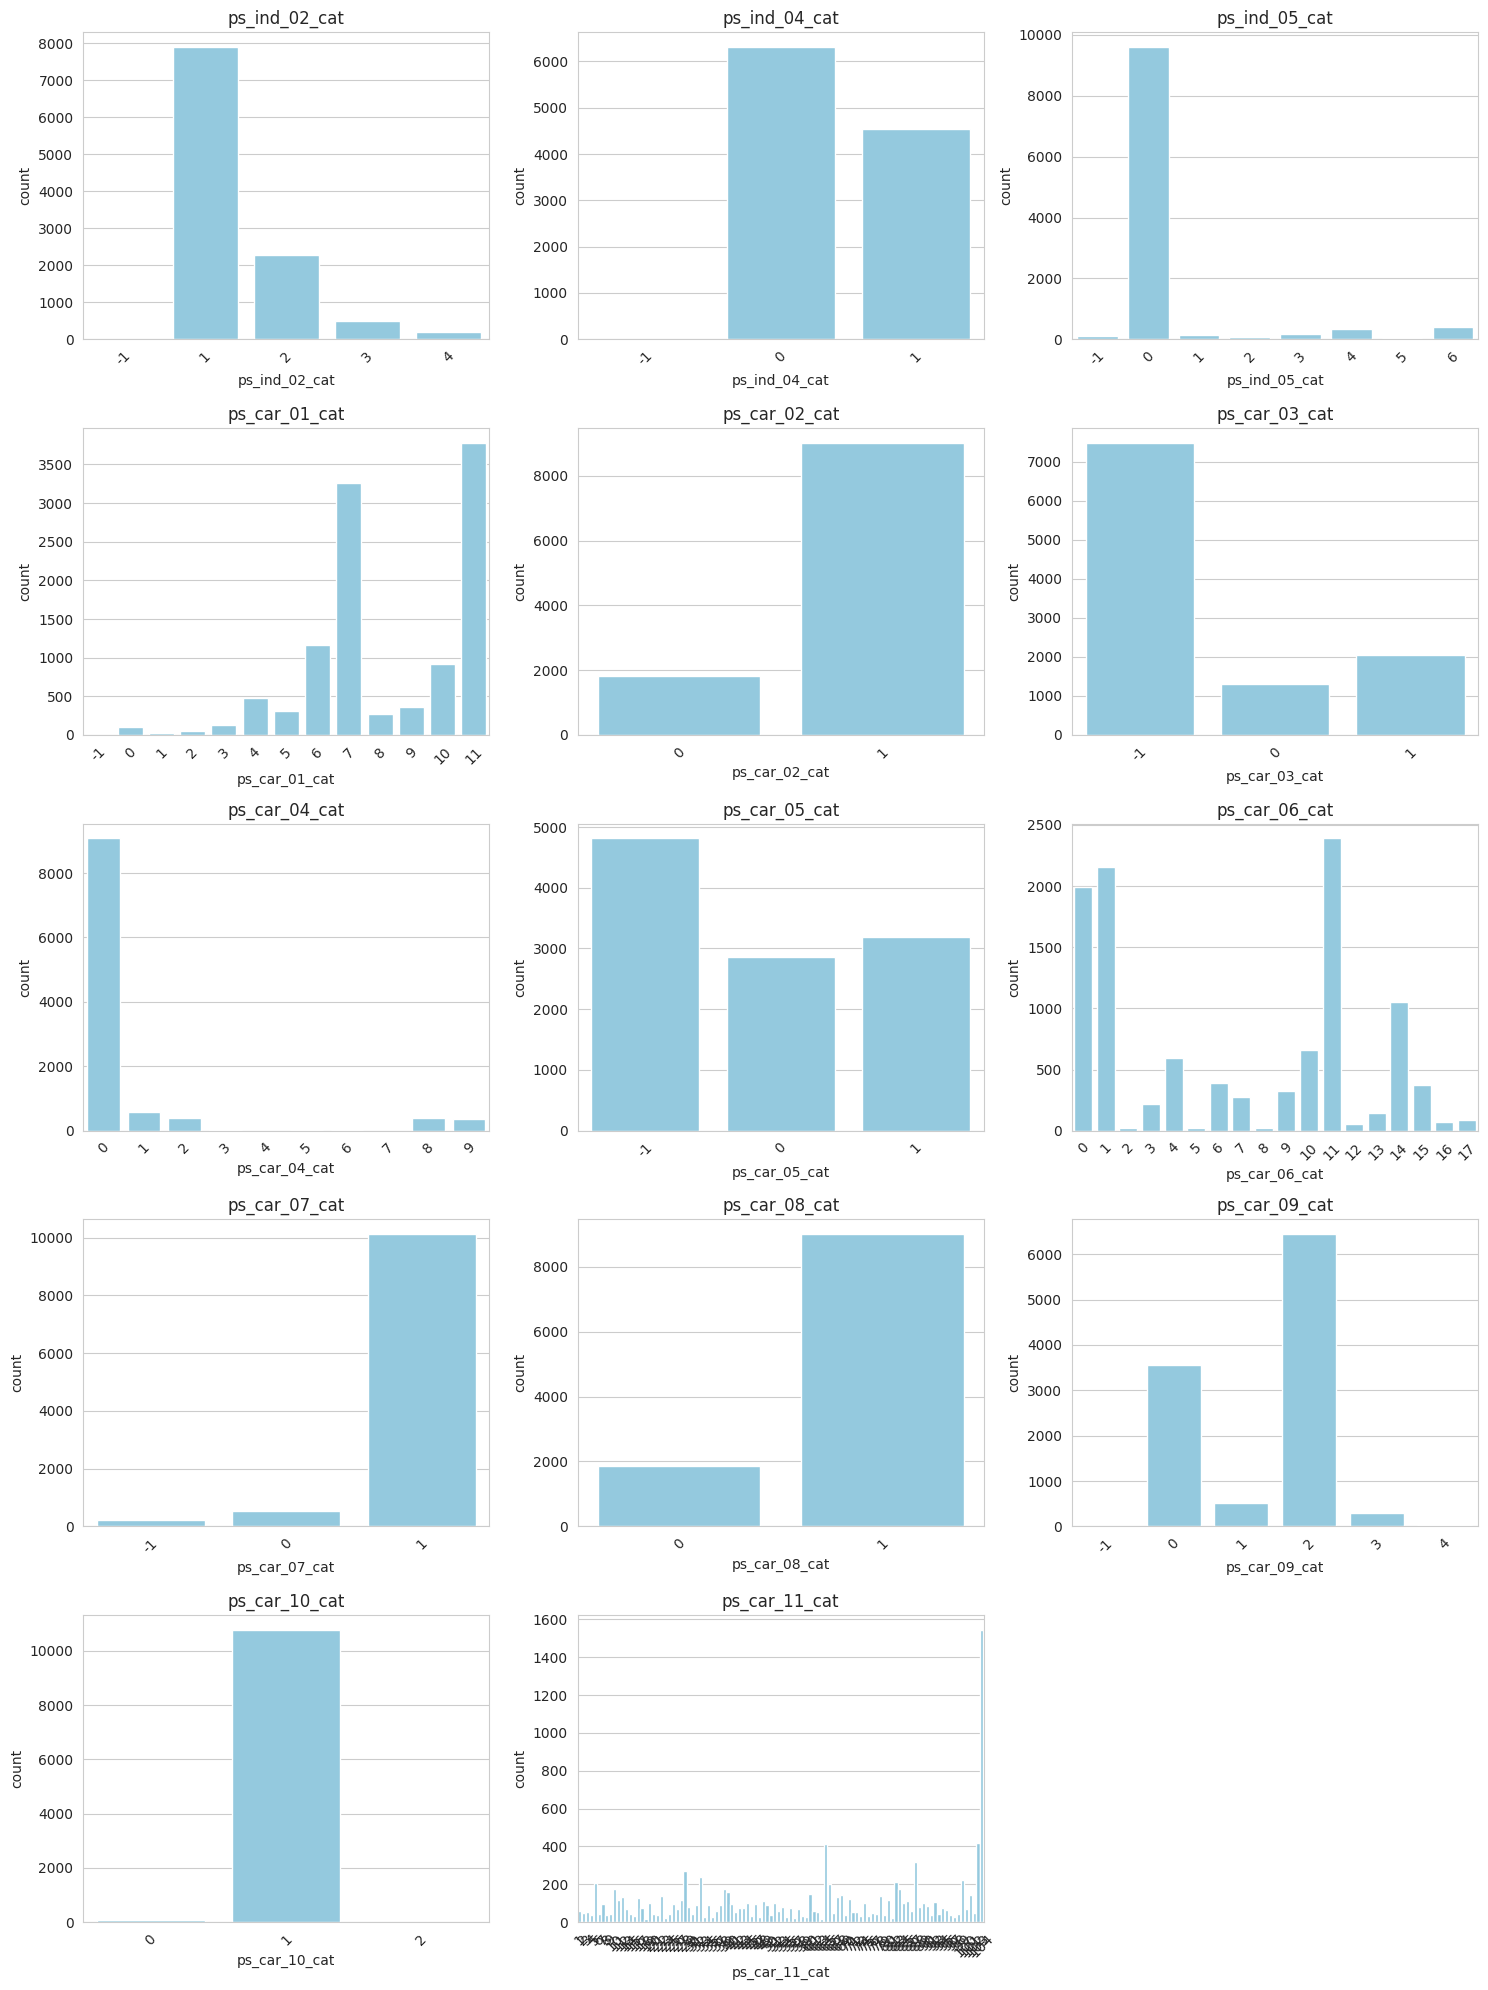

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cat_features = [col for col in train.columns if 'cat' in col]

n_cols = 3
n_rows = (len(cat_features) + n_cols - 1) // n_cols
plt.figure(figsize=(5*n_cols, 4*n_rows))

for i, col in enumerate(cat_features, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.countplot(x=col, data=train, color='skyblue')
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


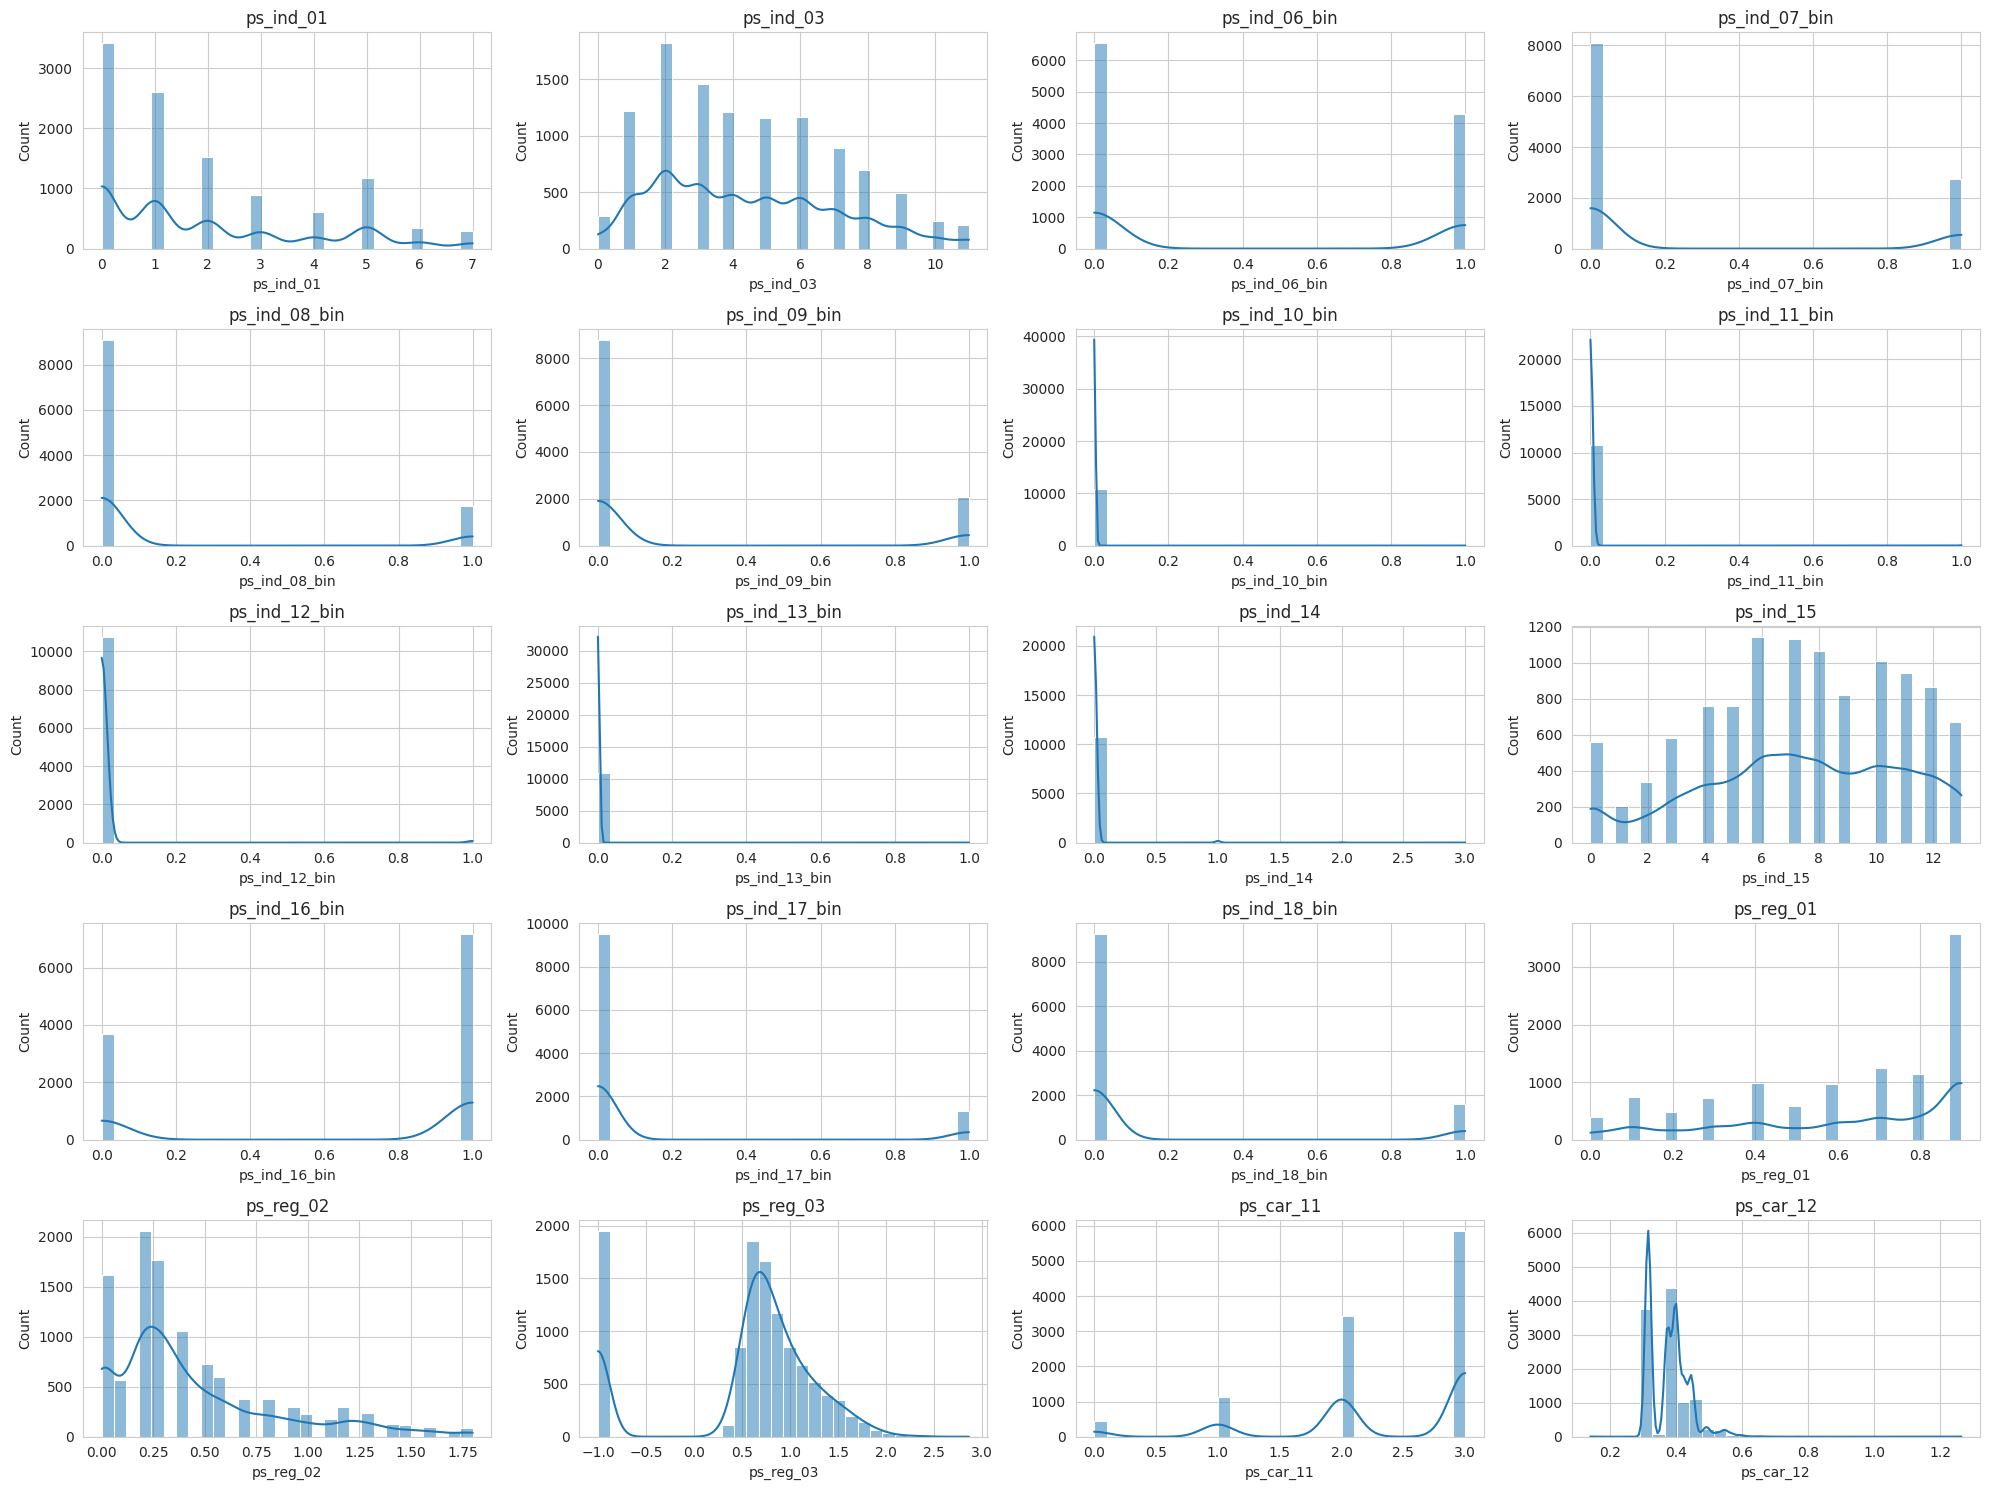

In [ ]:
num_features = [col for col in train.columns if col not in cat_features + ['id','target','ps_calc_15_bin','ps_calc_16_bin','ps_calc_17_bin','ps_calc_18_bin','ps_calc_19_bin','ps_calc_20_bin']]

plt.figure(figsize=(20,15))
for i, col in enumerate(num_features[:20]):  # ilk 20 numerical feature için
    plt.subplot(5,4,i+1)
    sns.histplot(train[col], bins=30, kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

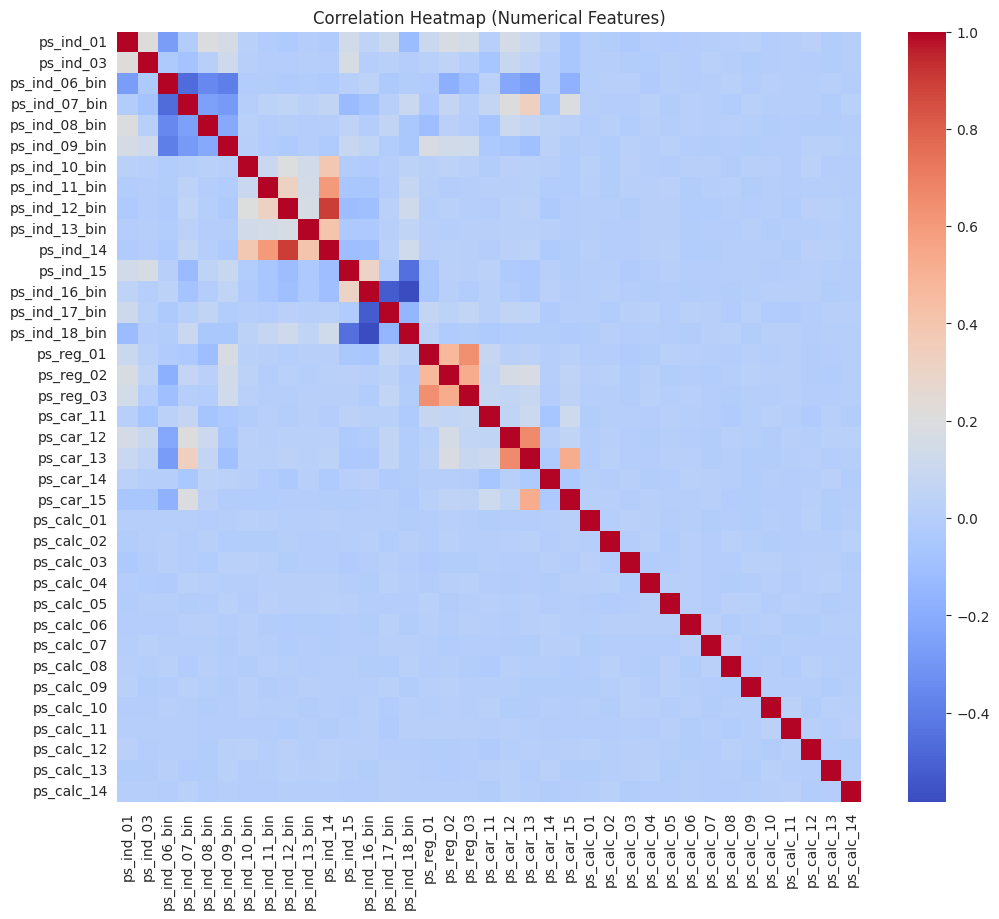

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(train[num_features].corr(), cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap (Numerical Features)')
plt.show()

**Handling Missing Values**

In [ ]:
missing_values = (train == -1).sum()
missing_values = missing_values[missing_values > 0]
print(missing_values)

ps_ind_02_cat       1
ps_ind_04_cat       1
ps_ind_05_cat     107
ps_reg_03        1951
ps_car_01_cat       1
ps_car_03_cat    7490
ps_car_05_cat    4813
ps_car_07_cat     209
ps_car_09_cat      18
ps_car_14         764
dtype: int64


In [ ]:
cat_cols = [col for col in train.columns if 'cat' in col or 'bin' in col]
num_cols = [col for col in train.columns if col not in cat_cols + ['id', 'target']]

In [ ]:
for col in cat_cols:
    if (train[col] == -1).any():
        train[col] = train[col].replace(-1, train[col].mode()[0])

In [ ]:
for col in num_cols:
    if (train[col] == -1).any():
        train[col] = train[col].replace(-1, train[col].median())

In [ ]:
for col in ['ps_car_03_cat', 'ps_car_05_cat']:
    train[col] = train[col].replace(-1, 'missing')
    test[col] = test[col].replace(-1, 'missing')

In [ ]:
missing_values = (train == -1).sum()
missing_values = missing_values[missing_values > 0]
print(missing_values)

Series([], dtype: int64)


**Outlier Analysis**

In [ ]:
for col in num_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((train[col] < Q1 - 1.5*IQR) | (train[col] > Q3 + 1.5*IQR)).sum()
    print(f'{col}: {outliers} outliers')

ps_ind_01: 0 outliers
ps_ind_03: 0 outliers
ps_ind_14: 109 outliers
ps_ind_15: 0 outliers
ps_reg_01: 0 outliers
ps_reg_02: 712 outliers
ps_reg_03: 663 outliers
ps_car_11: 457 outliers
ps_car_12: 285 outliers
ps_car_13: 519 outliers
ps_car_14: 580 outliers
ps_car_15: 518 outliers
ps_calc_01: 0 outliers
ps_calc_02: 0 outliers
ps_calc_03: 0 outliers
ps_calc_04: 644 outliers
ps_calc_05: 0 outliers
ps_calc_06: 30 outliers
ps_calc_07: 8 outliers
ps_calc_08: 20 outliers
ps_calc_09: 4 outliers
ps_calc_10: 59 outliers
ps_calc_11: 109 outliers
ps_calc_12: 649 outliers
ps_calc_13: 98 outliers
ps_calc_14: 291 outliers


In [ ]:
import pandas as pd

# Numeric columns
num_cols = [col for col in train.columns if col not in cat_cols + ['id', 'target']]

# IQR-based winsorizing
for col in num_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Winsorizing
    train[col] = train[col].clip(lower=lower_bound, upper=upper_bound)

In [ ]:
# Outlier check after winsorizing
outlier_counts_after = {}
for col in num_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((train[col] < lower_bound) | (train[col] > upper_bound)).sum()
    outlier_counts_after[col] = outliers

# Show only columns with remaining outliers
{col: count for col, count in outlier_counts_after.items() if count > 0}

{}

**Data Visualization After Handling Missing Values**

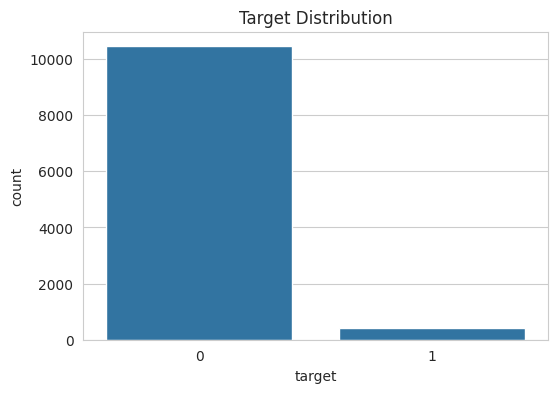

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=train)
plt.title('Target Distribution')
plt.show()

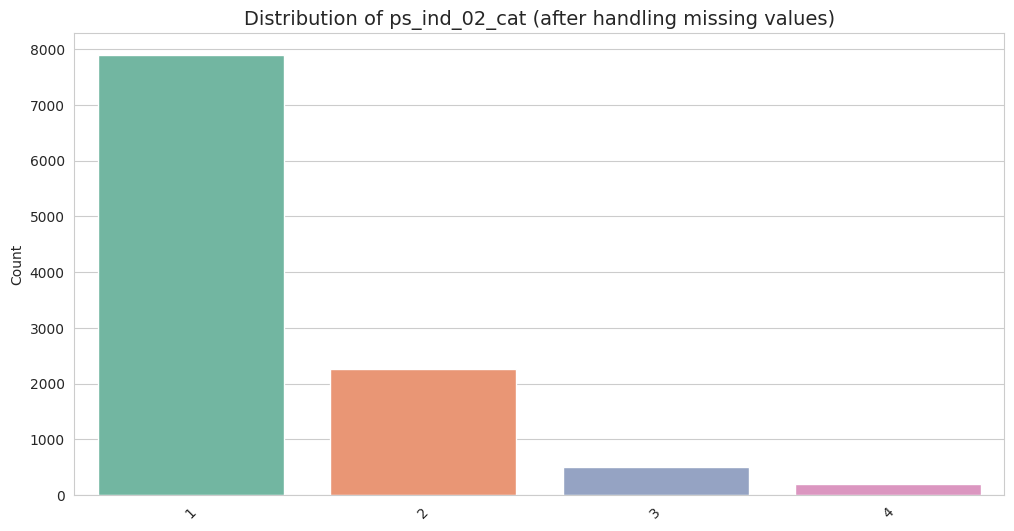

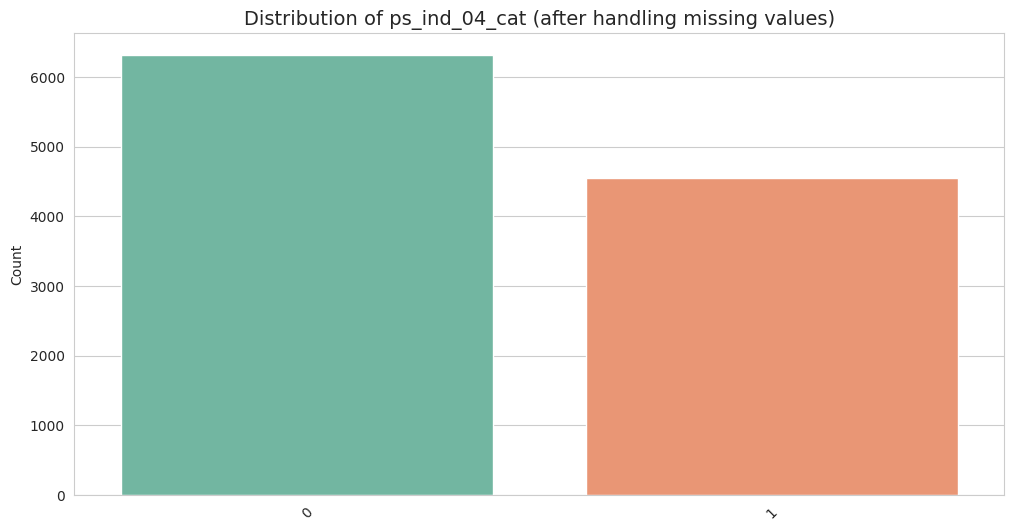

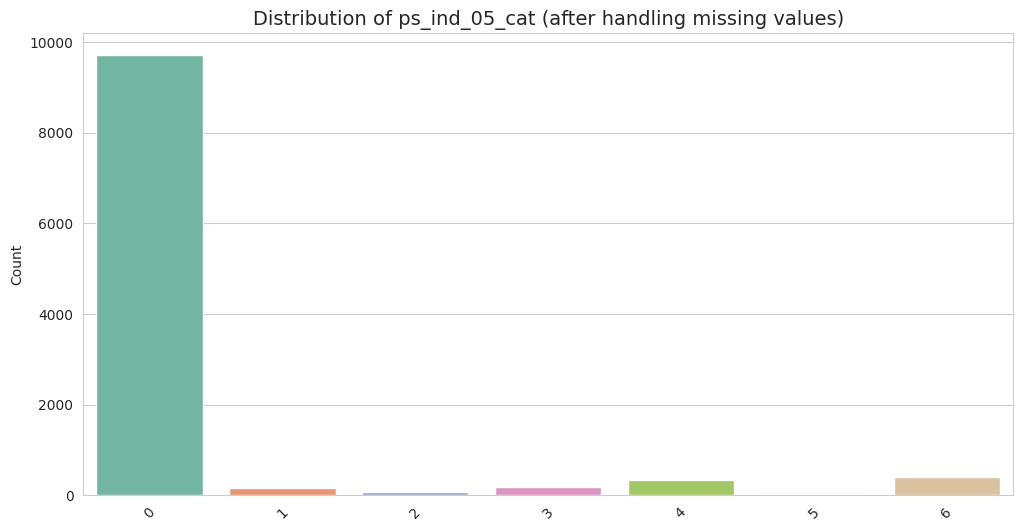

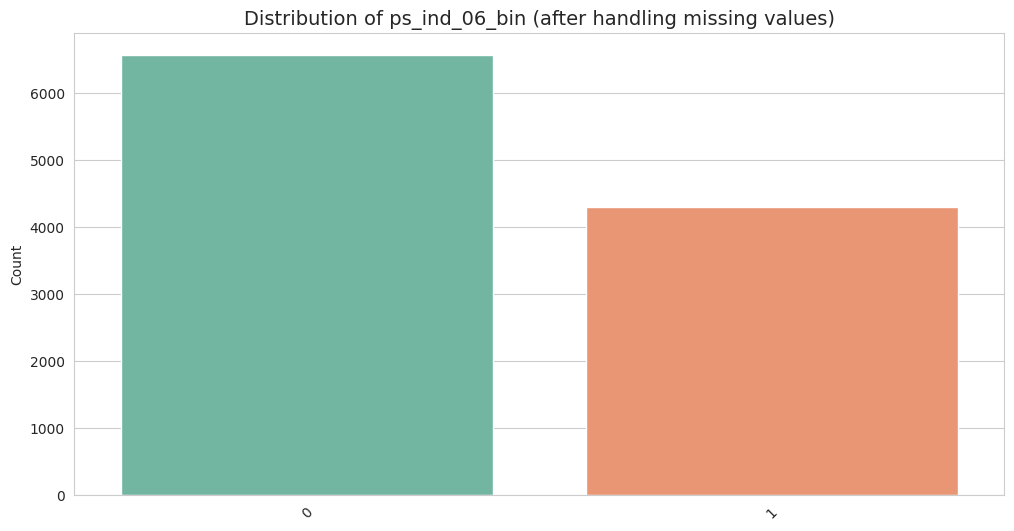

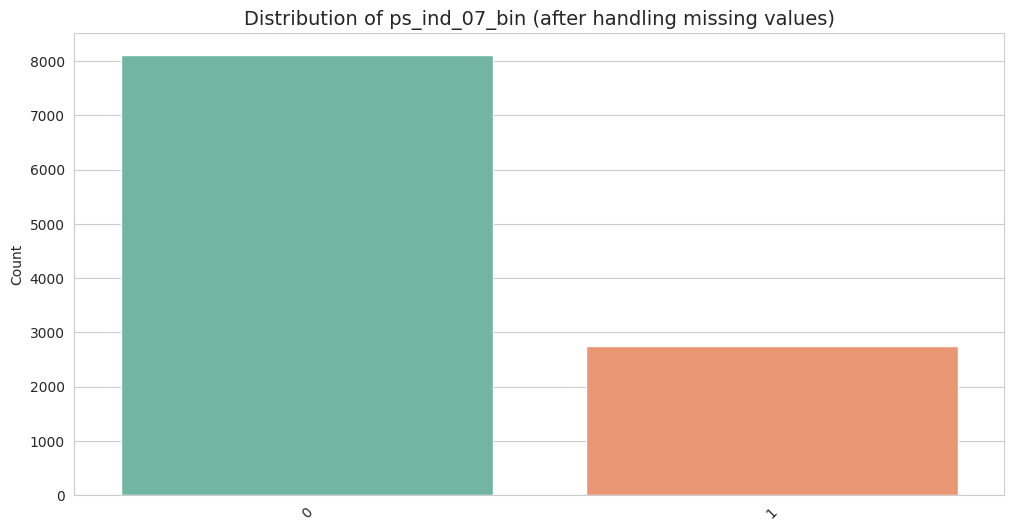

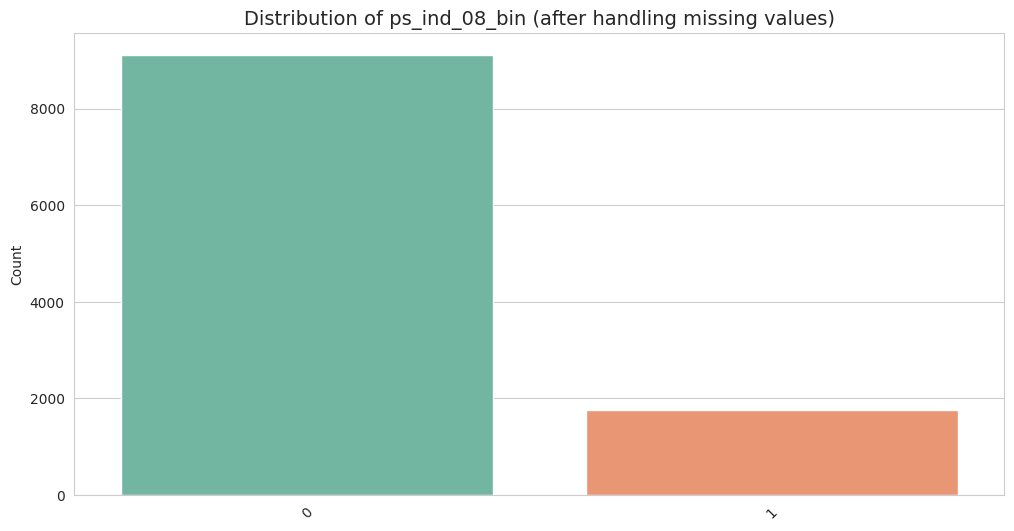

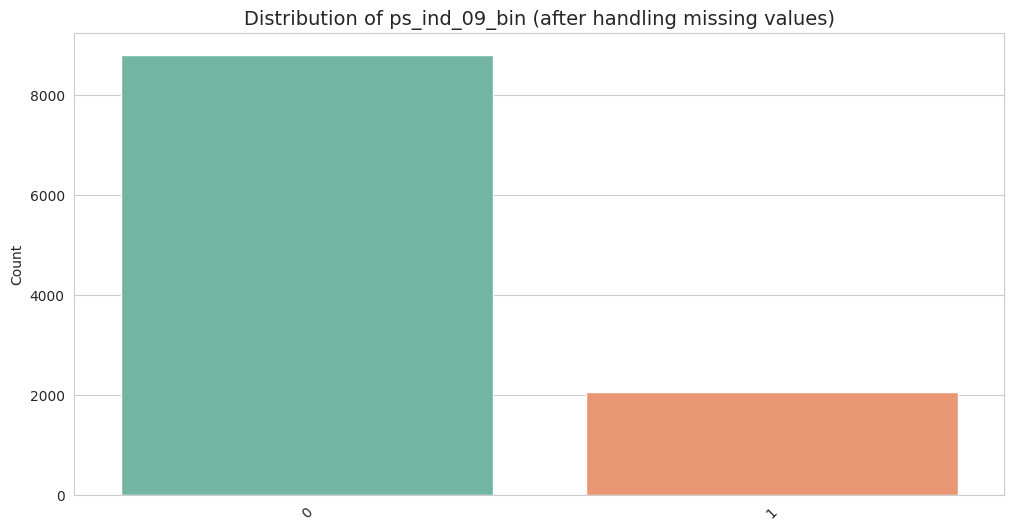

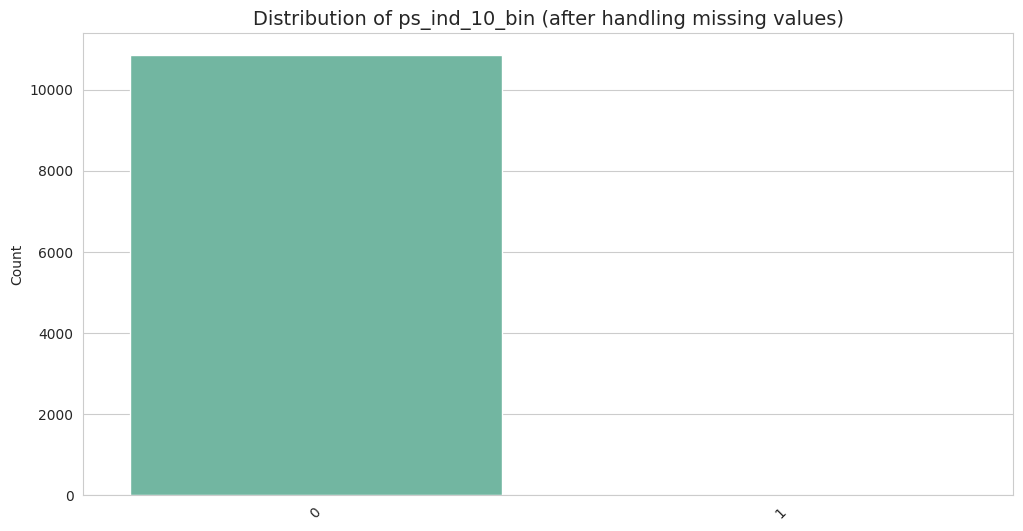

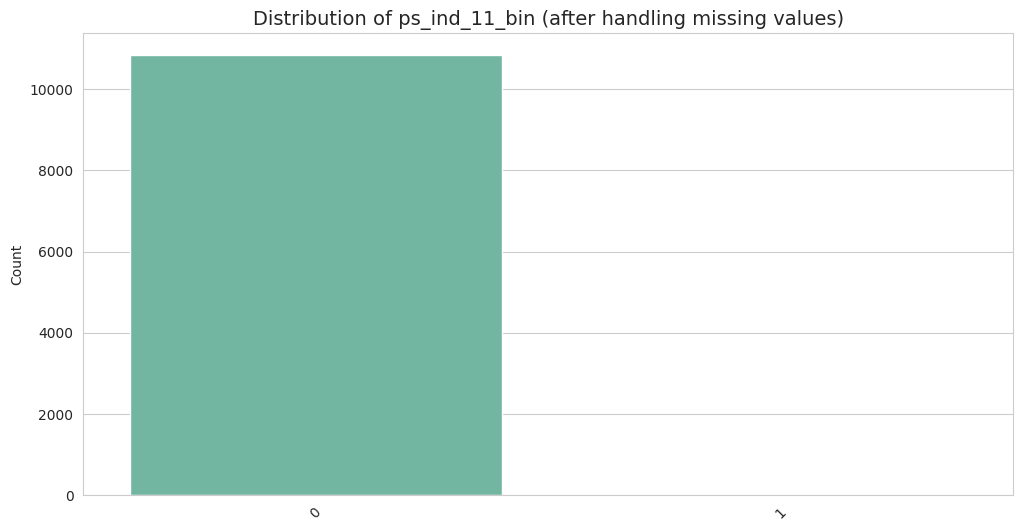

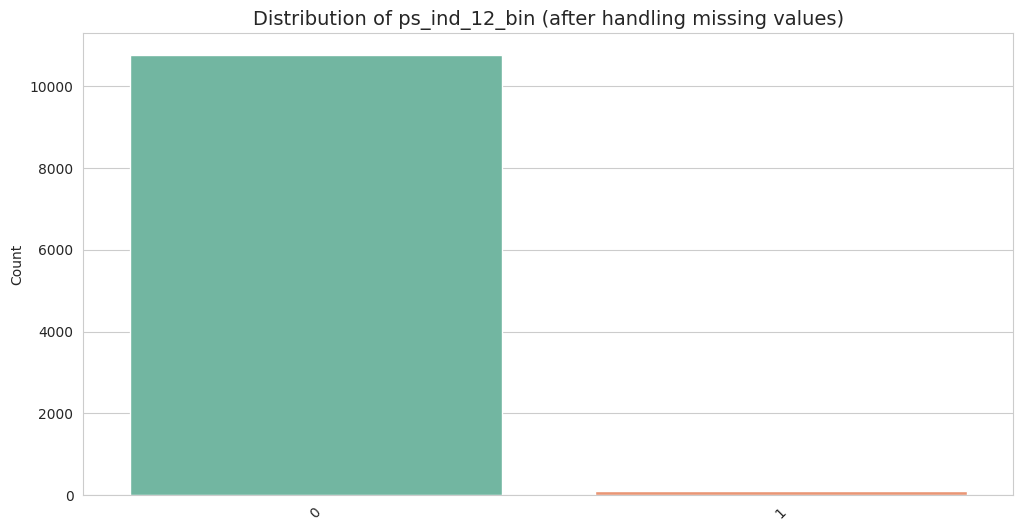

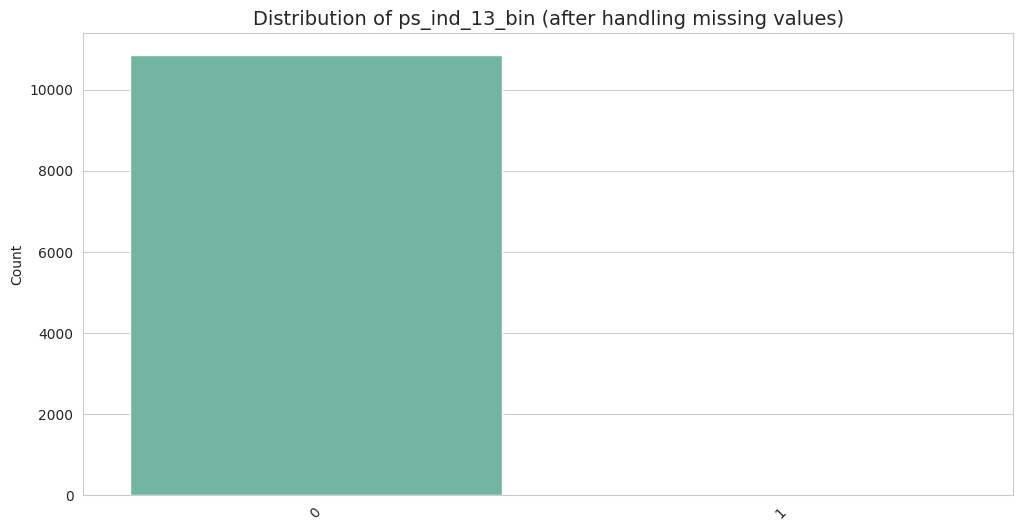

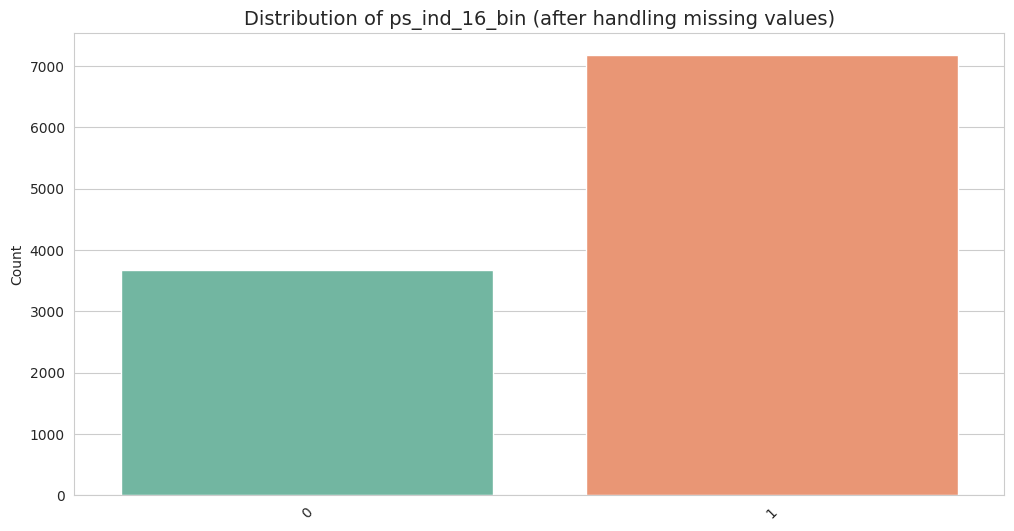

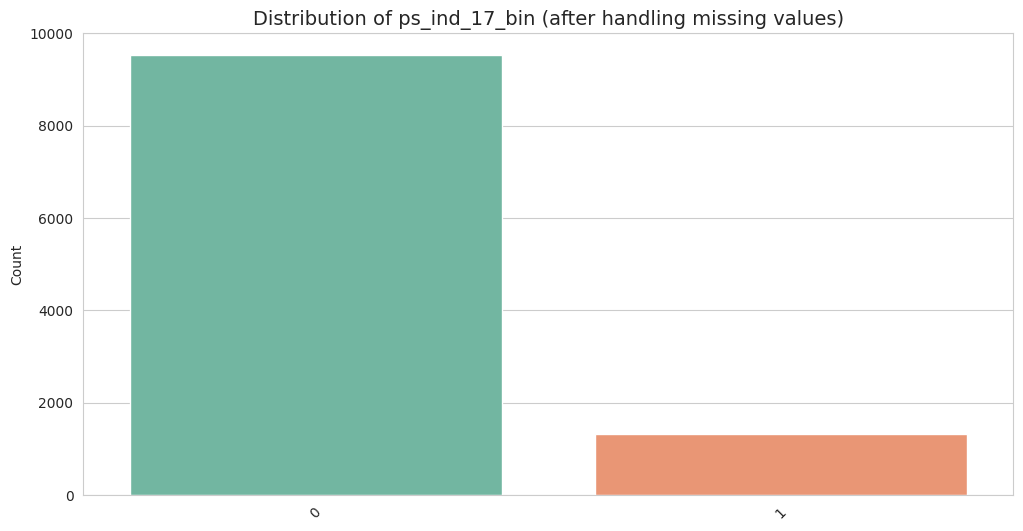

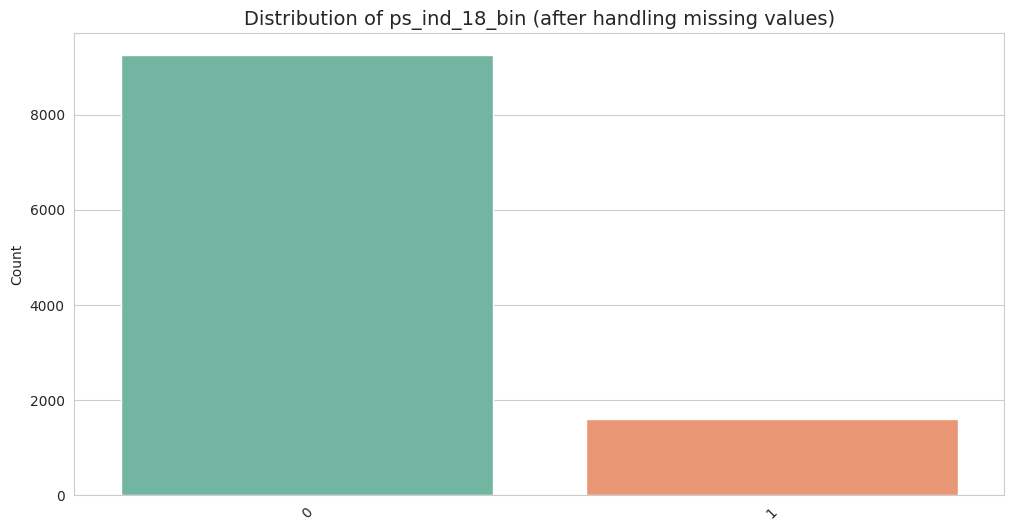

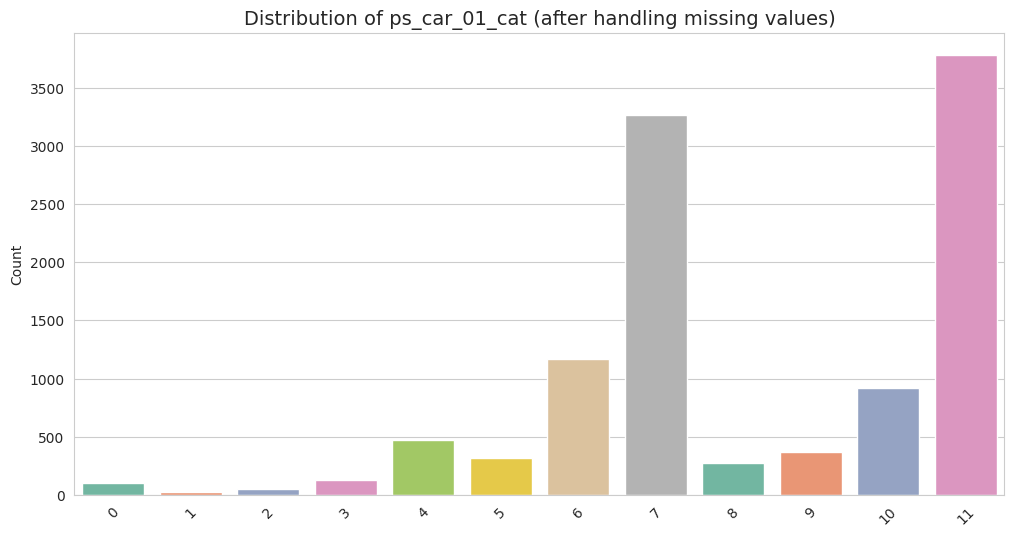

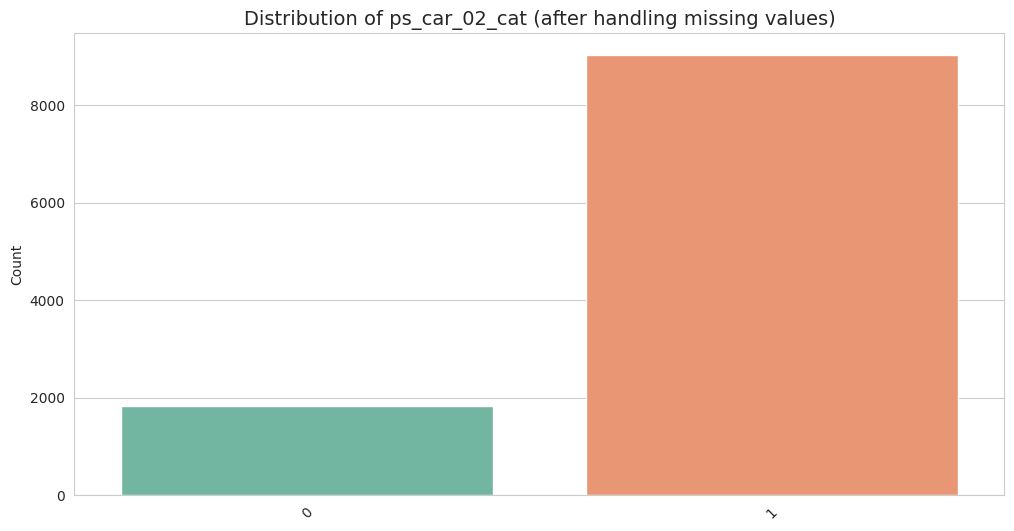

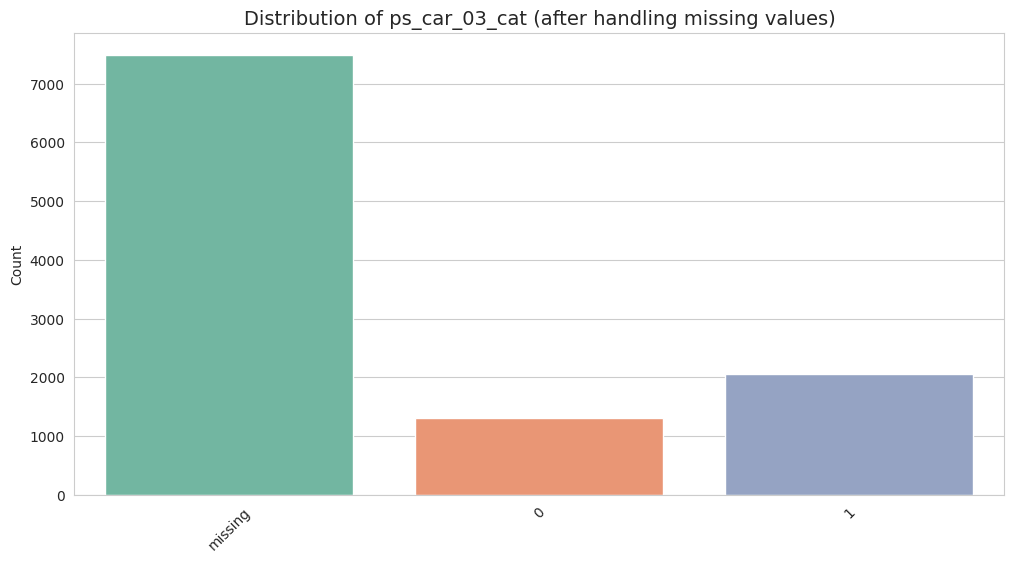

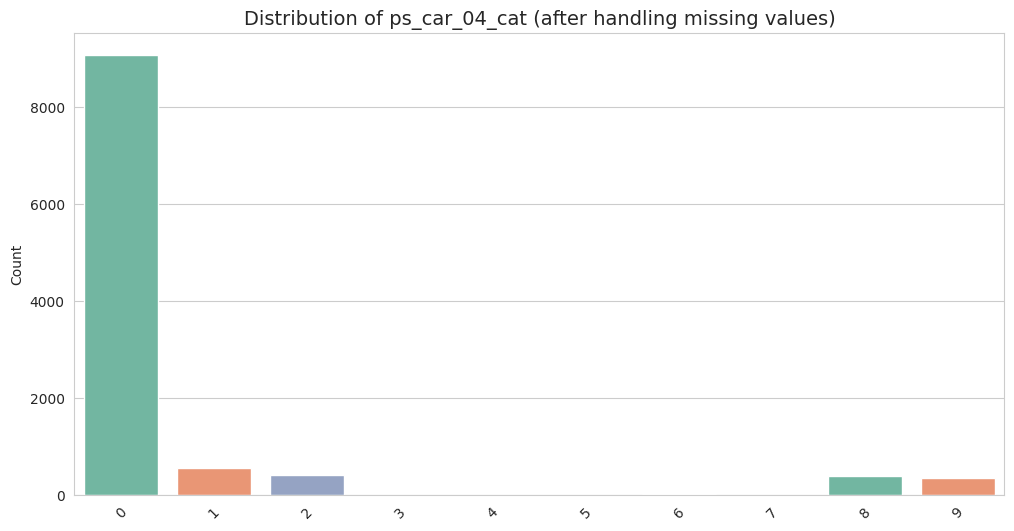

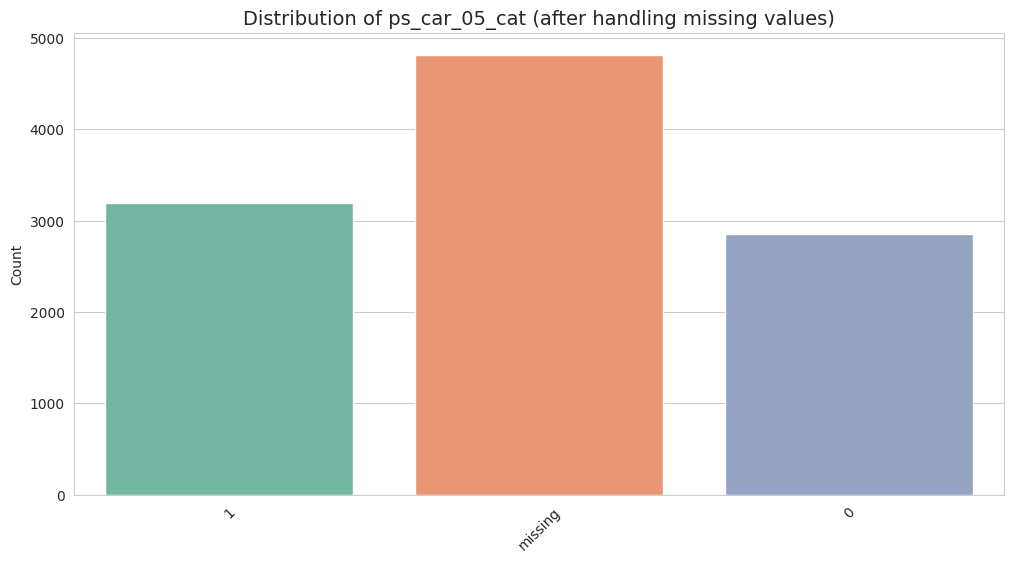

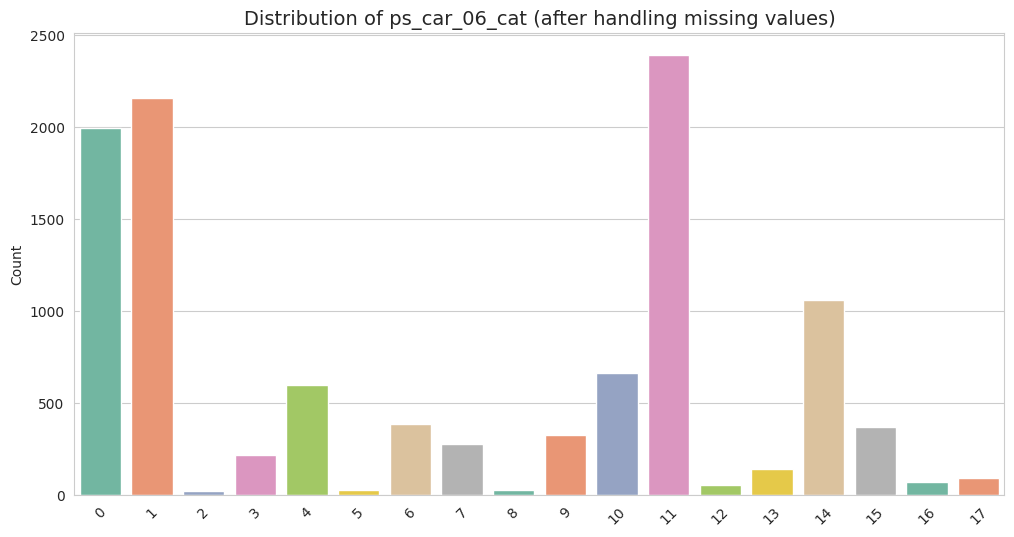

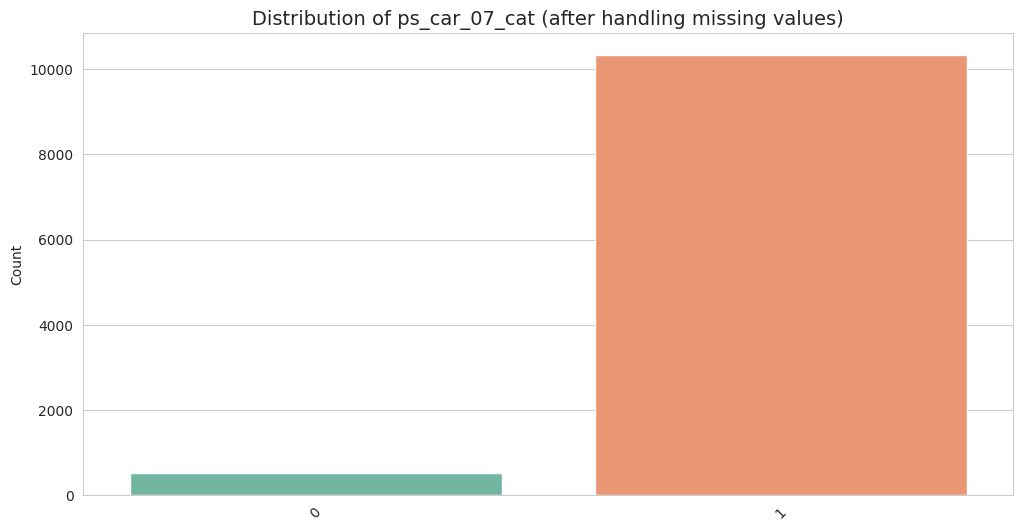

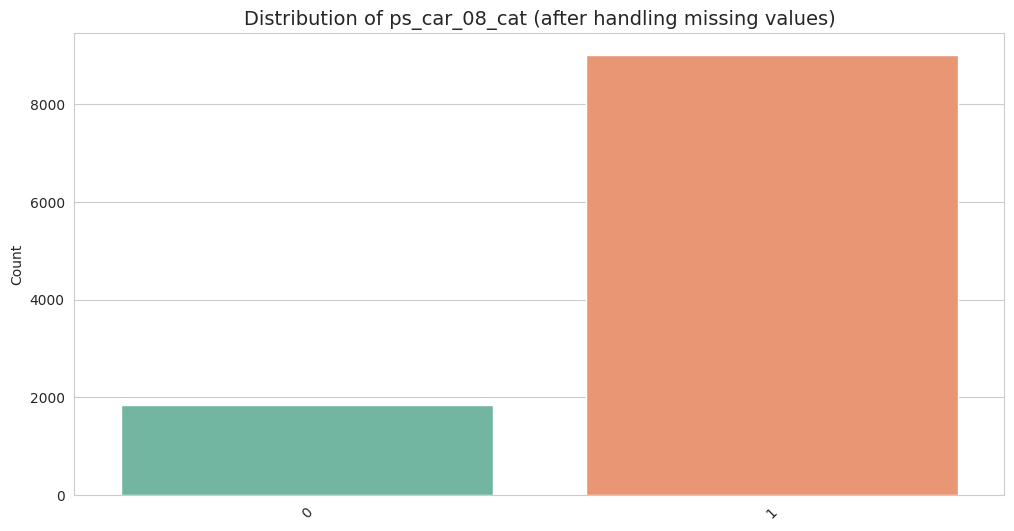

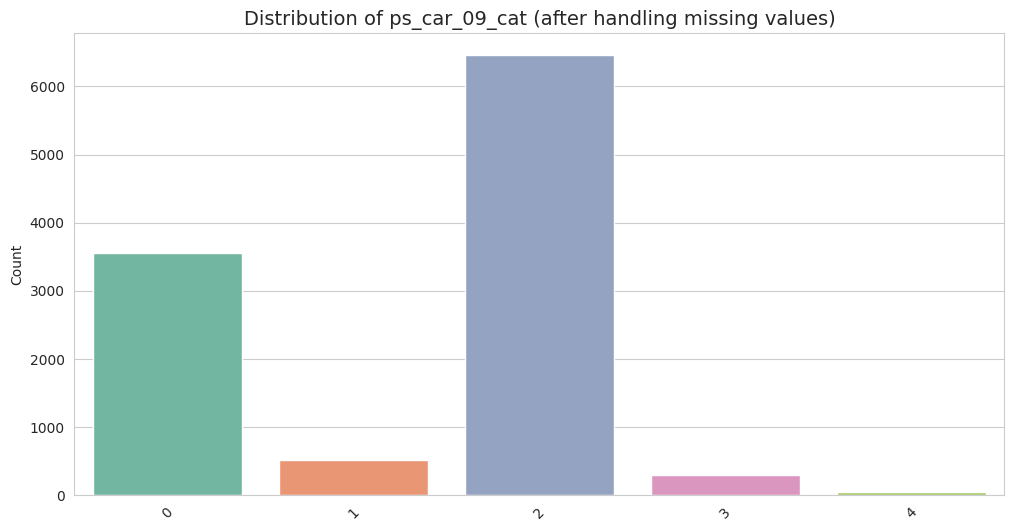

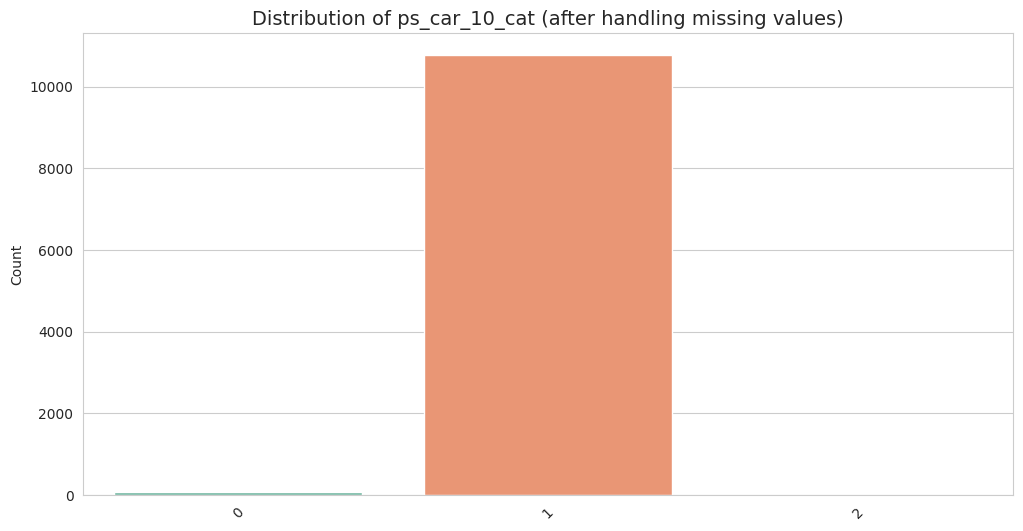

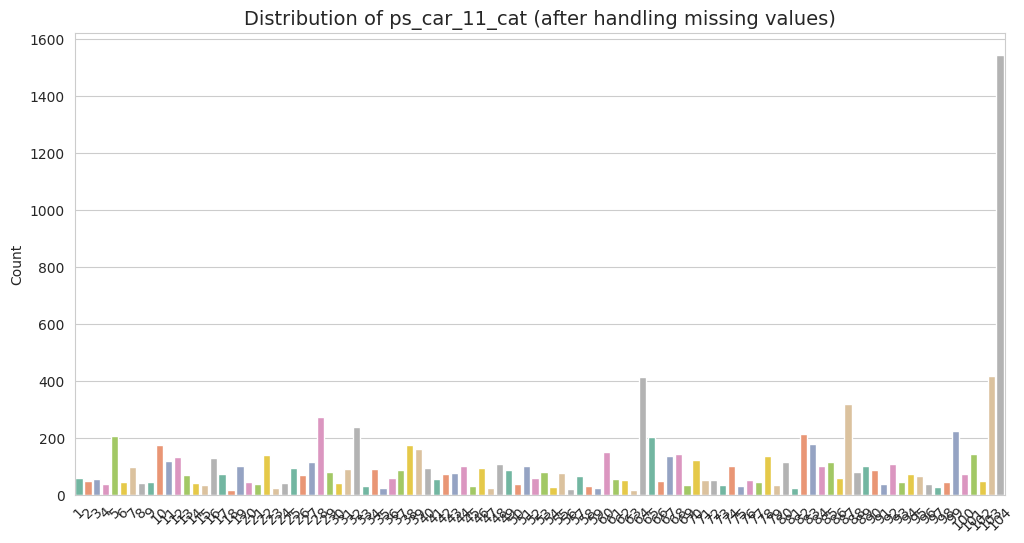

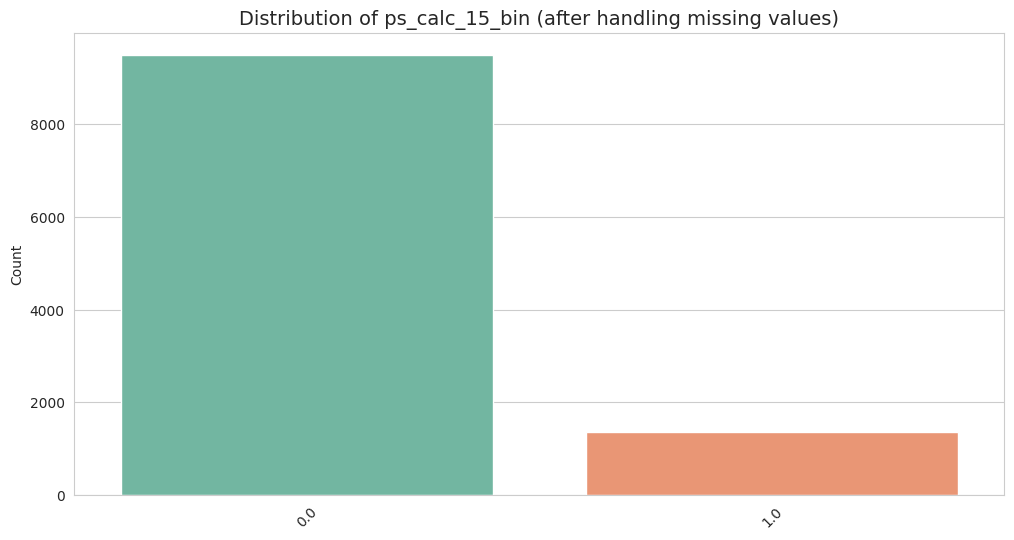

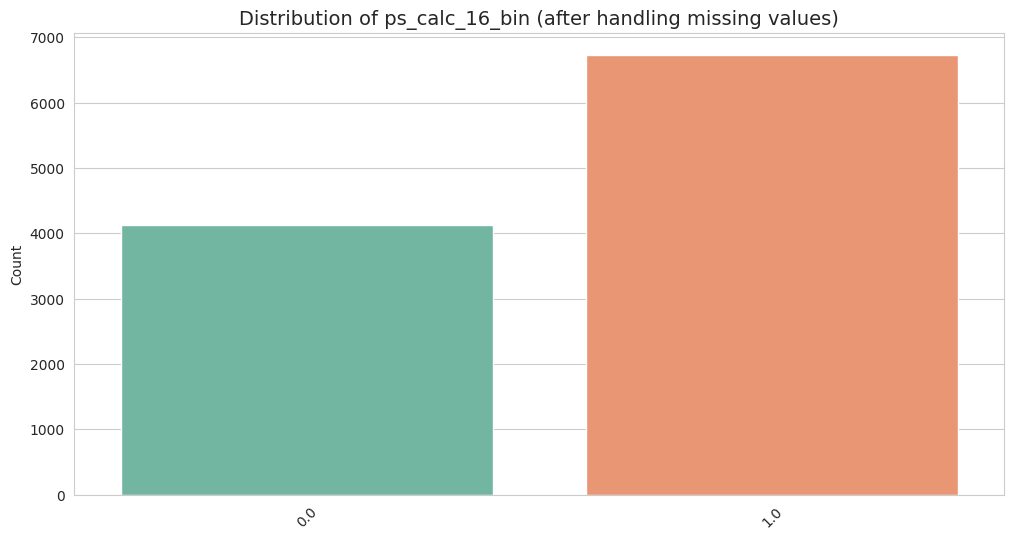

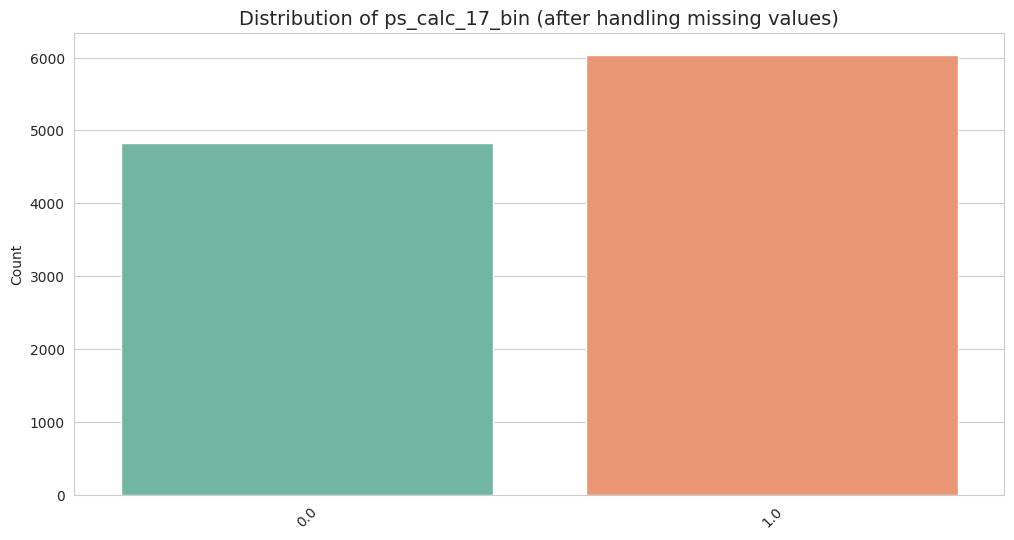

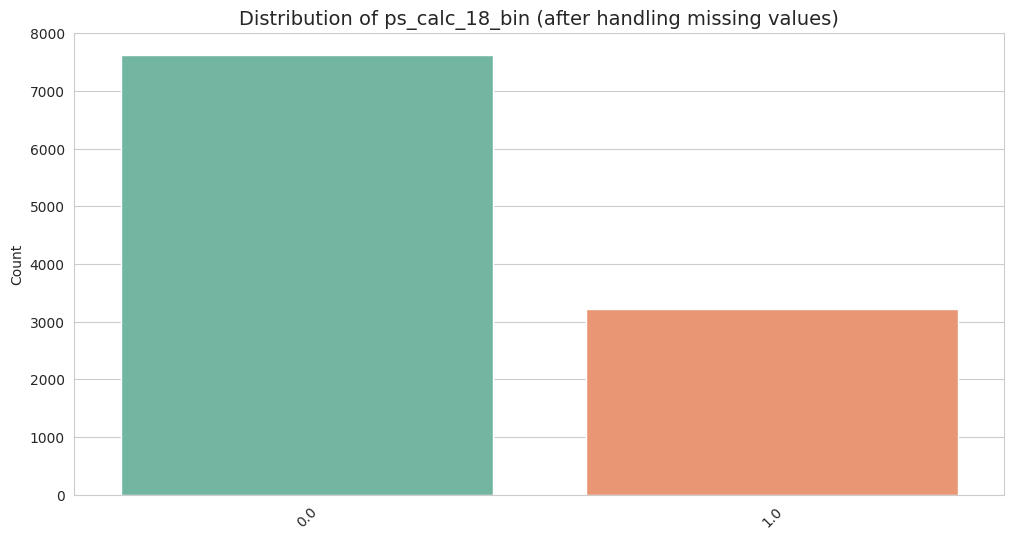

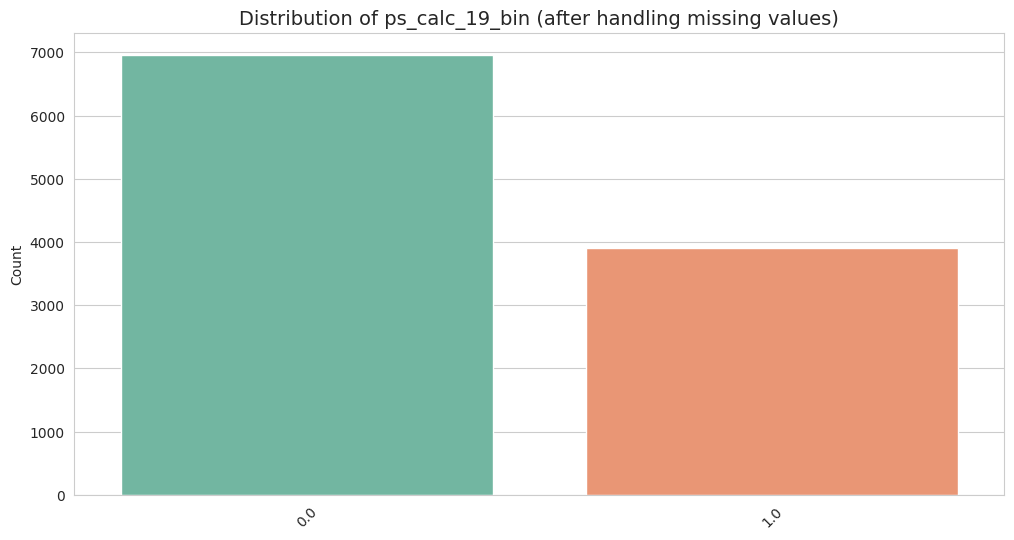

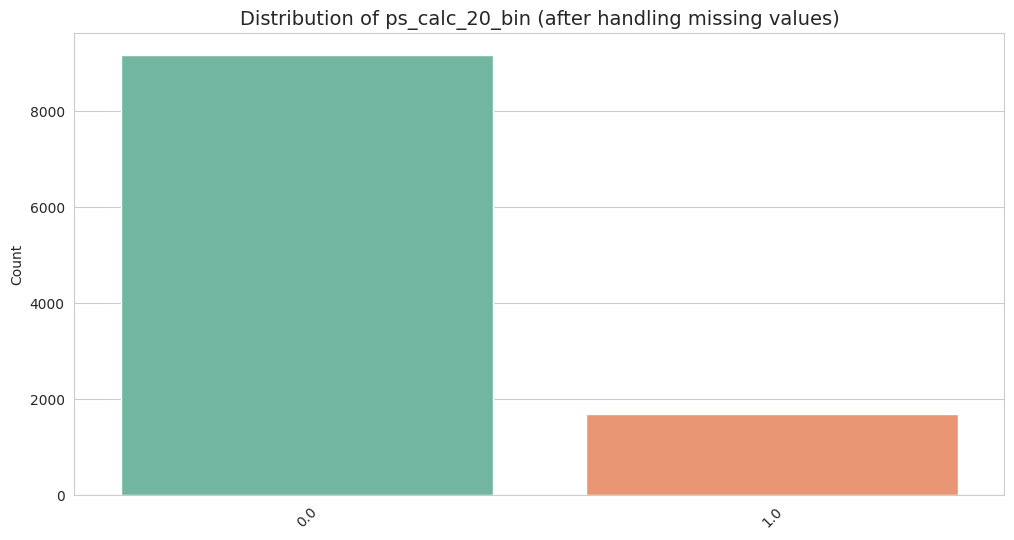

In [ ]:
# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12,6)

# Categorical columns
for col in cat_cols:
    plt.figure()
    sns.countplot(x=col, data=train, palette='Set2')
    plt.title(f'Distribution of {col} (after handling missing values)', fontsize=14)
    plt.xticks(rotation=45)
    plt.xlabel('')
    plt.ylabel('Count')
    plt.show()

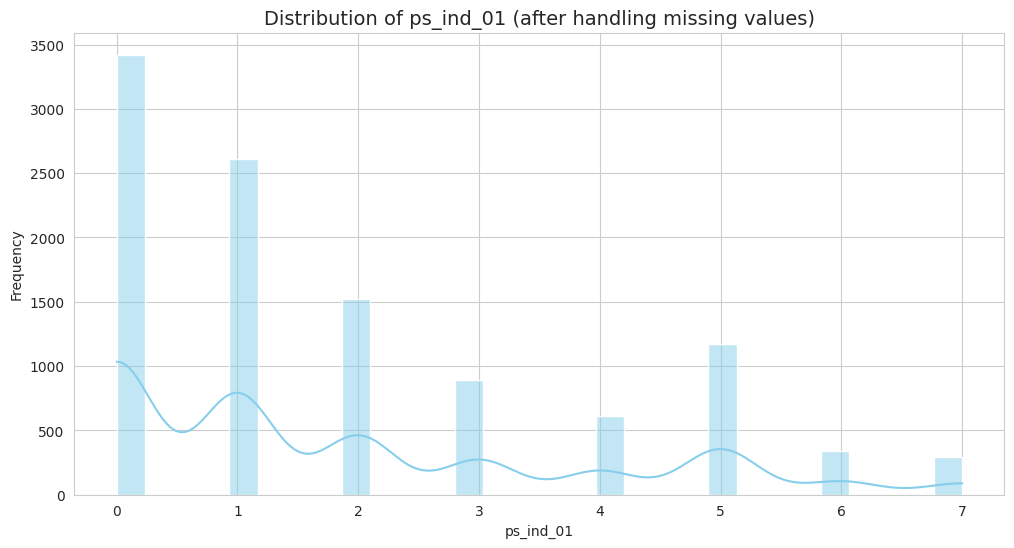

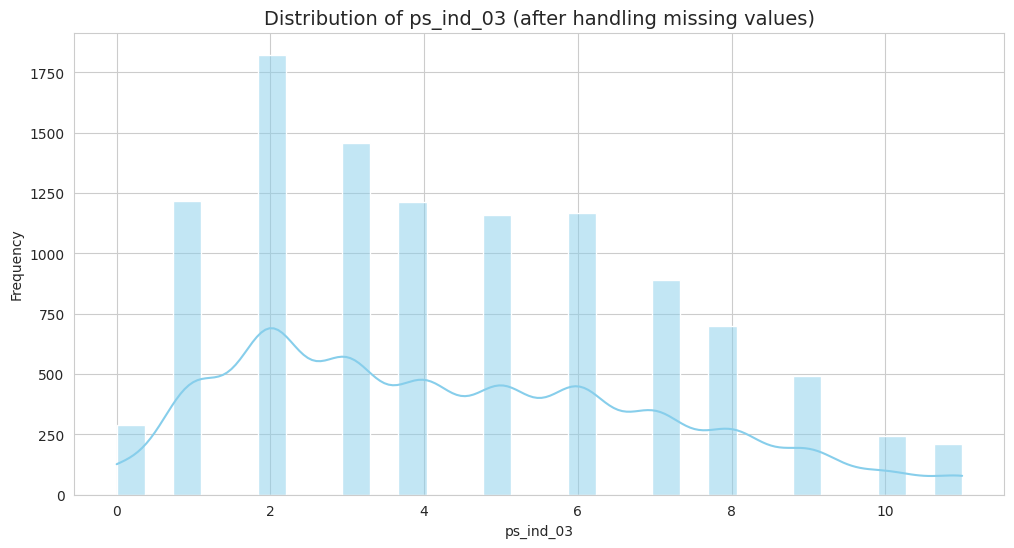

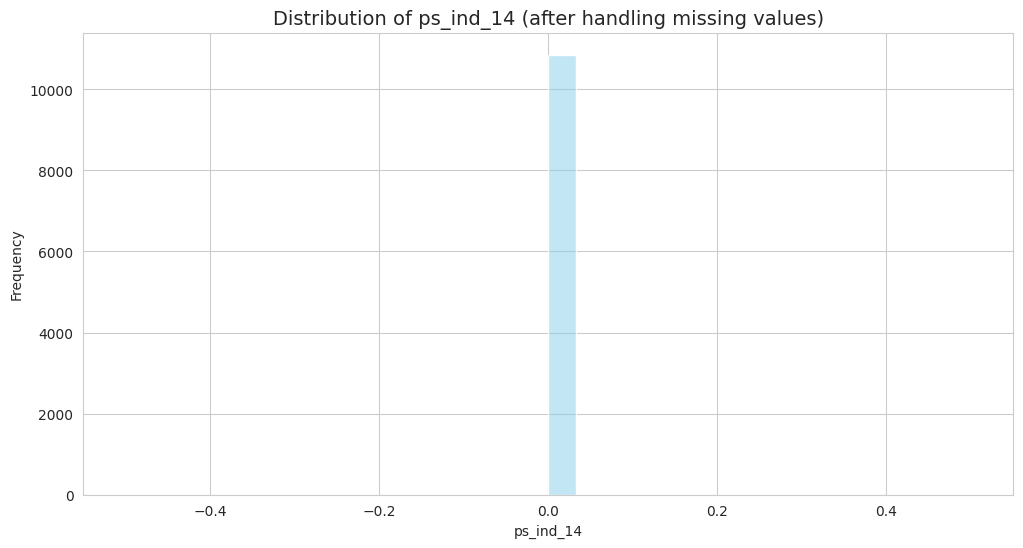

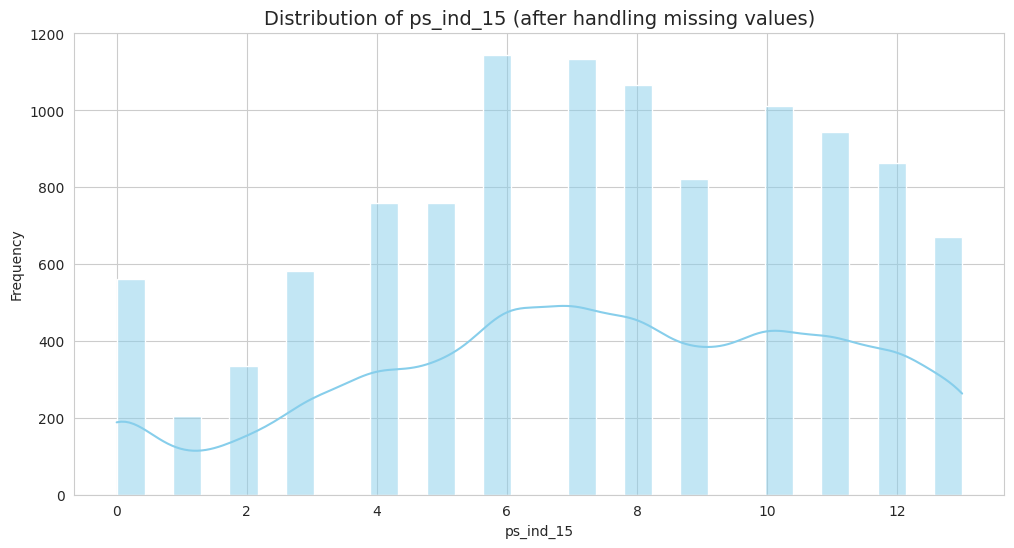

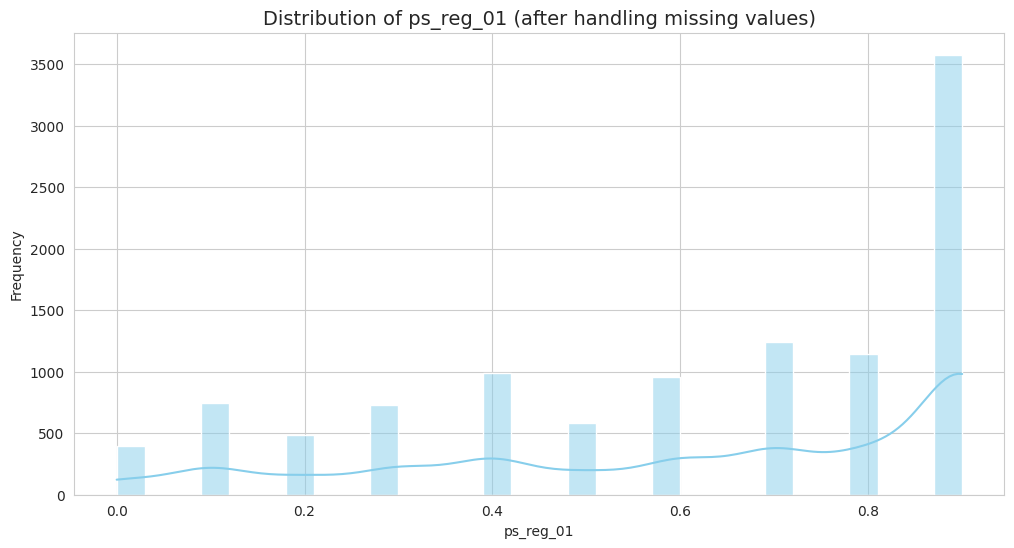

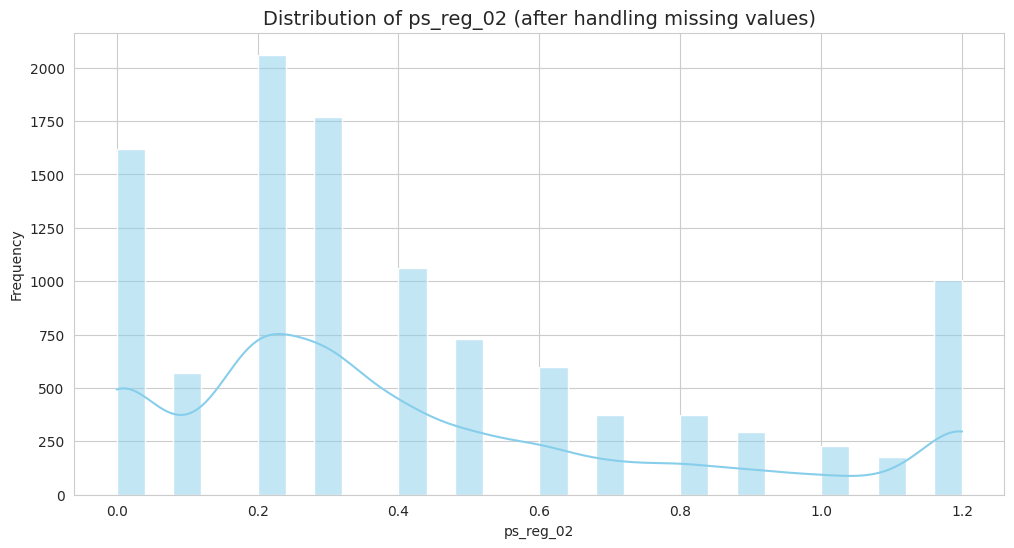

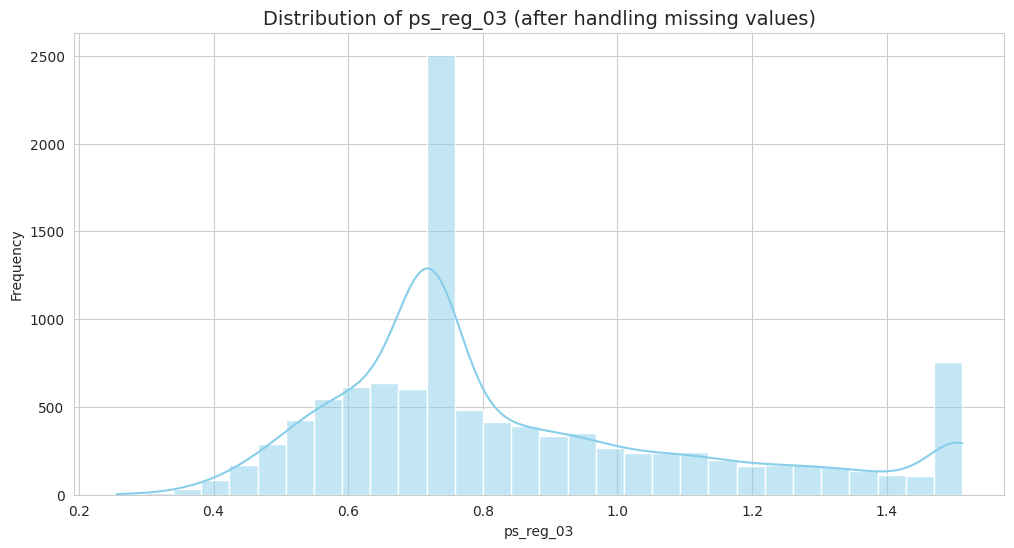

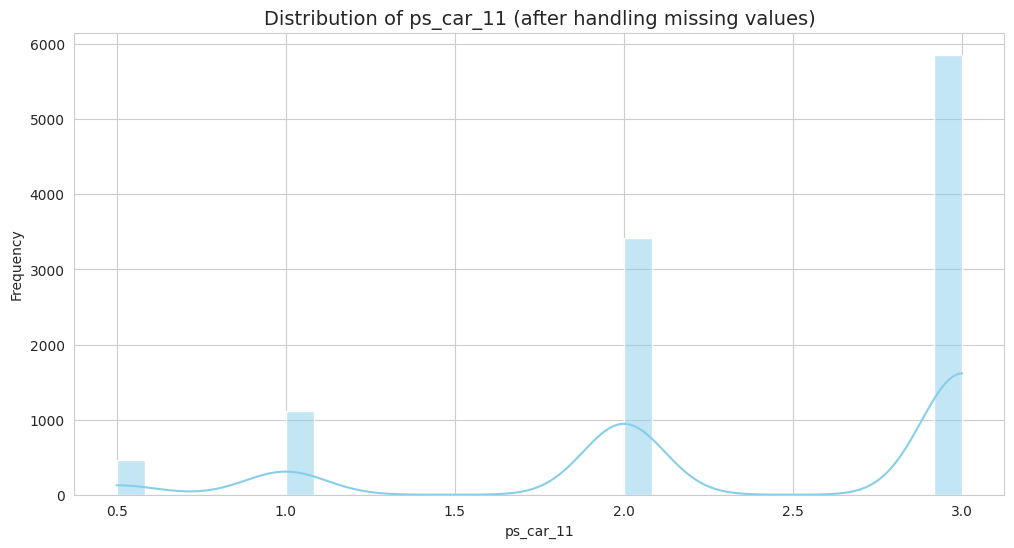

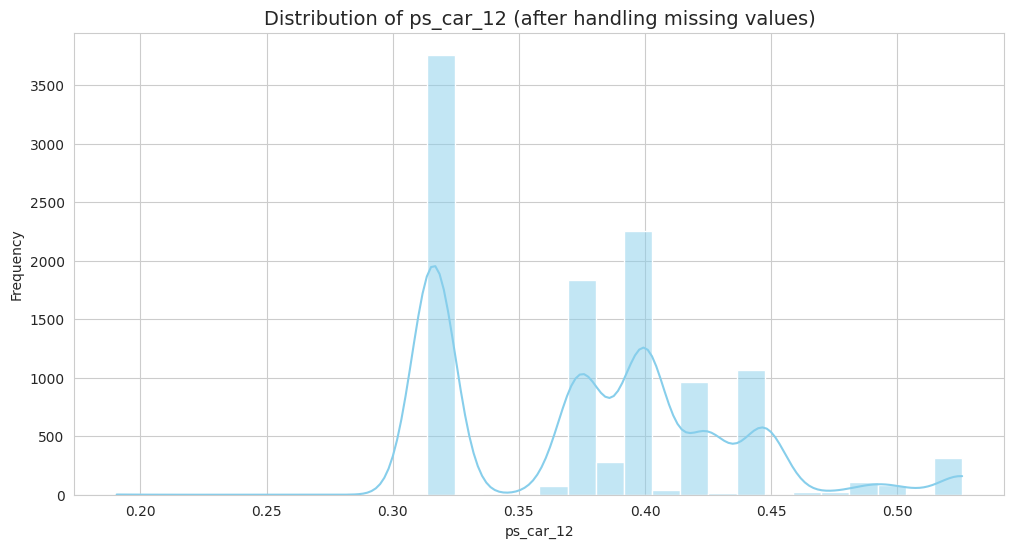

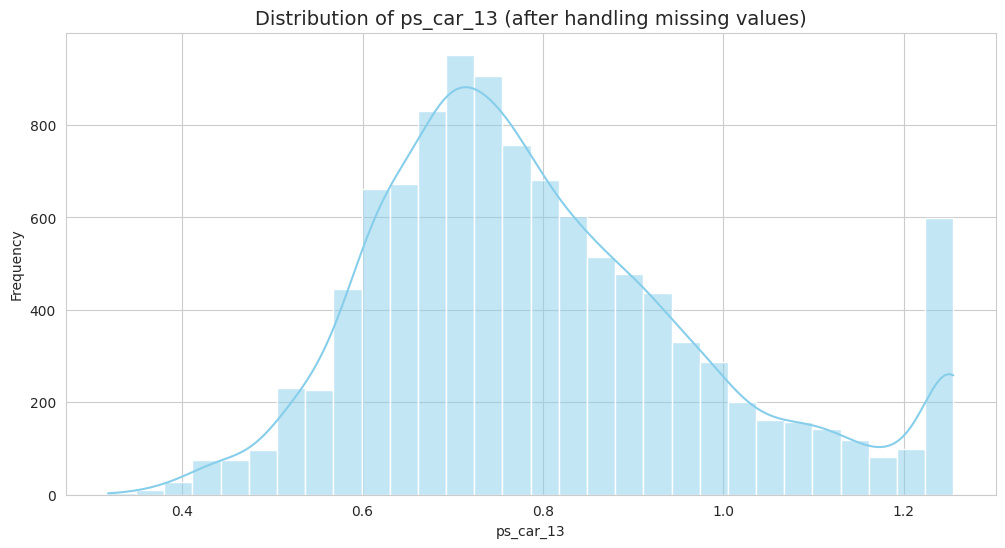

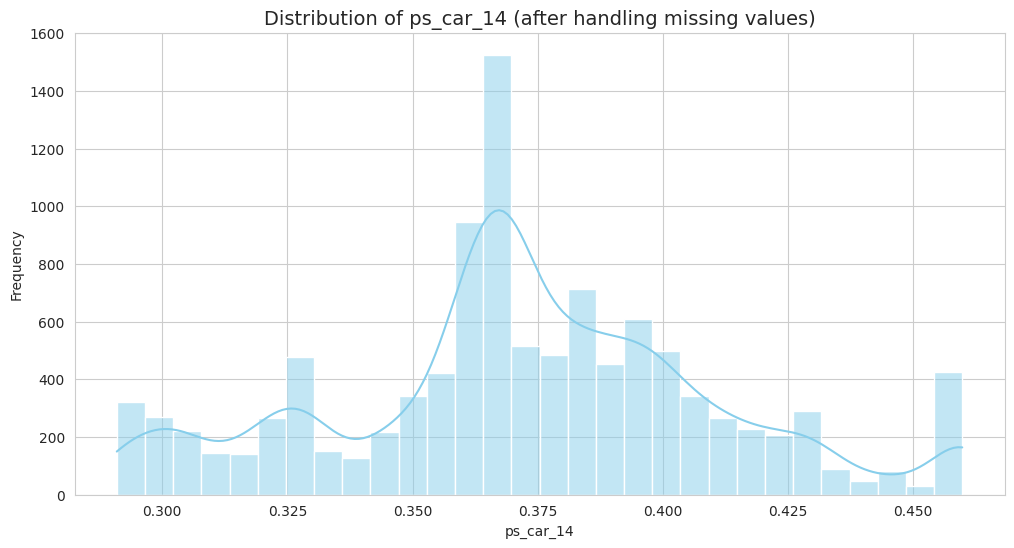

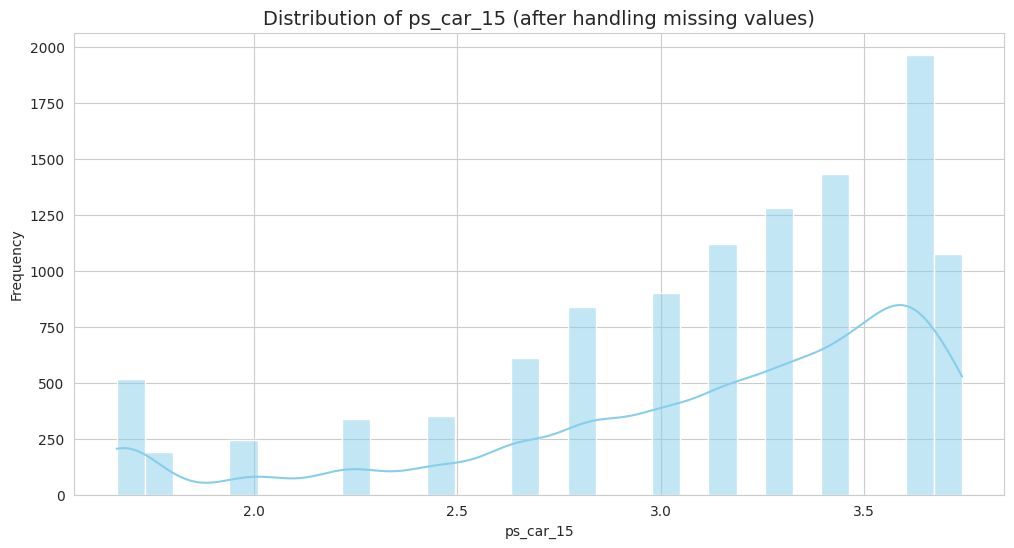

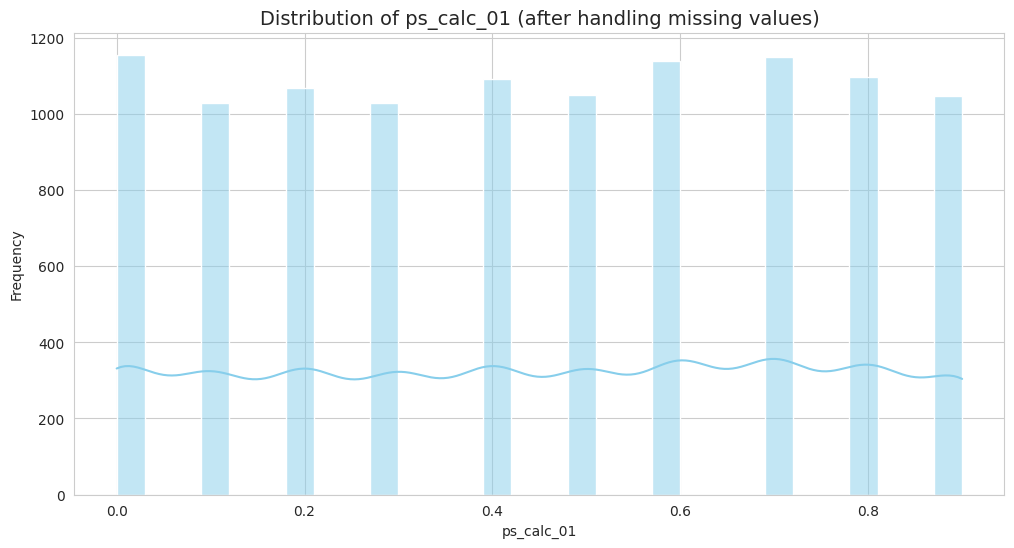

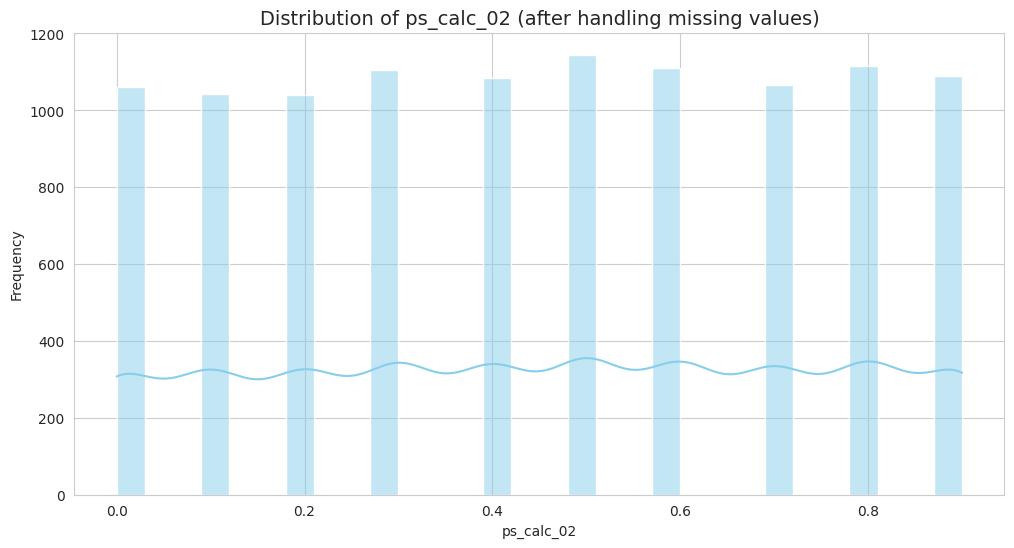

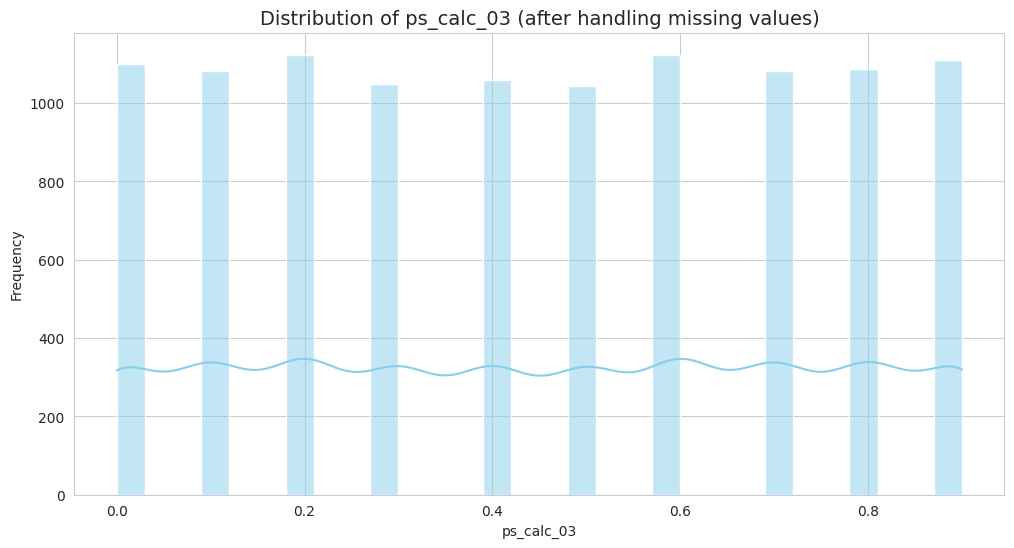

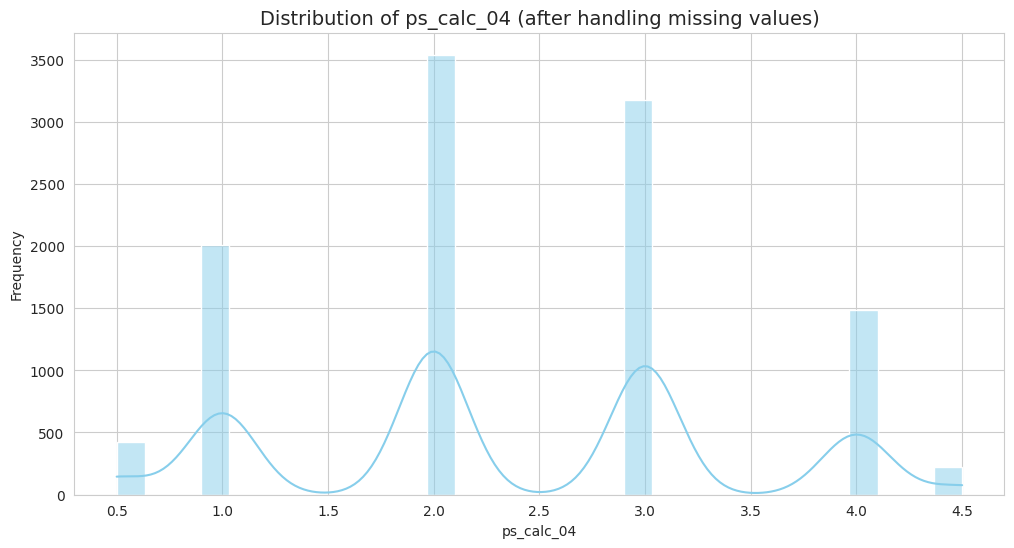

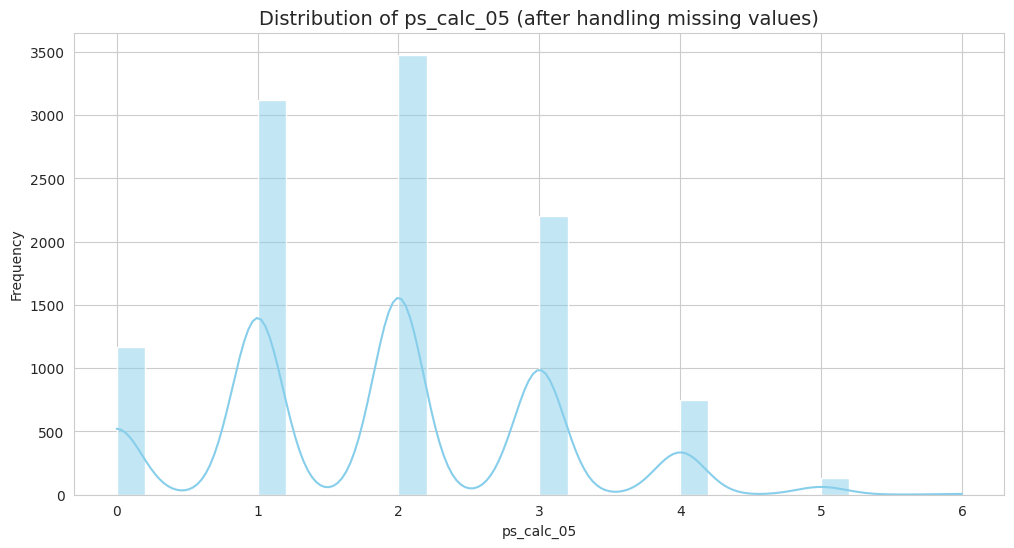

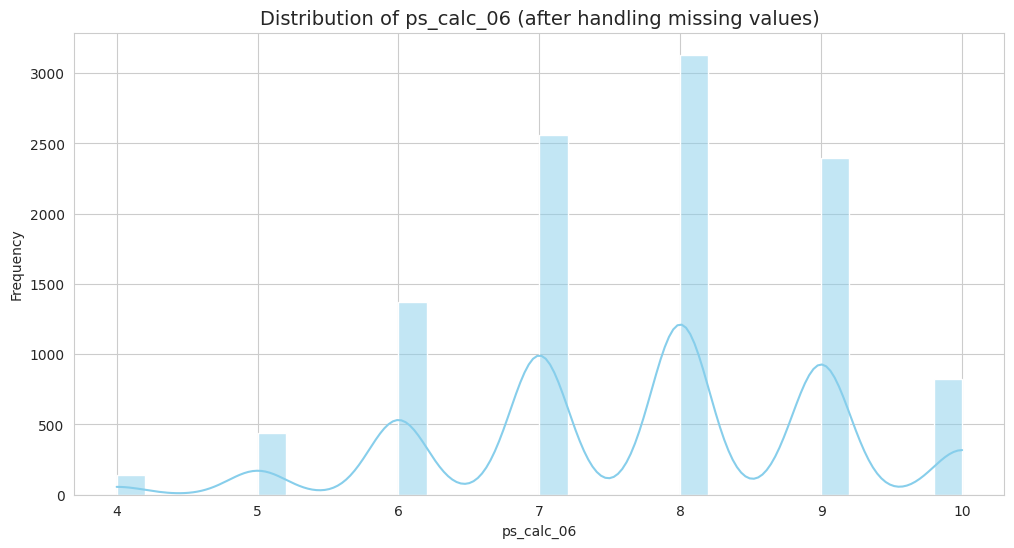

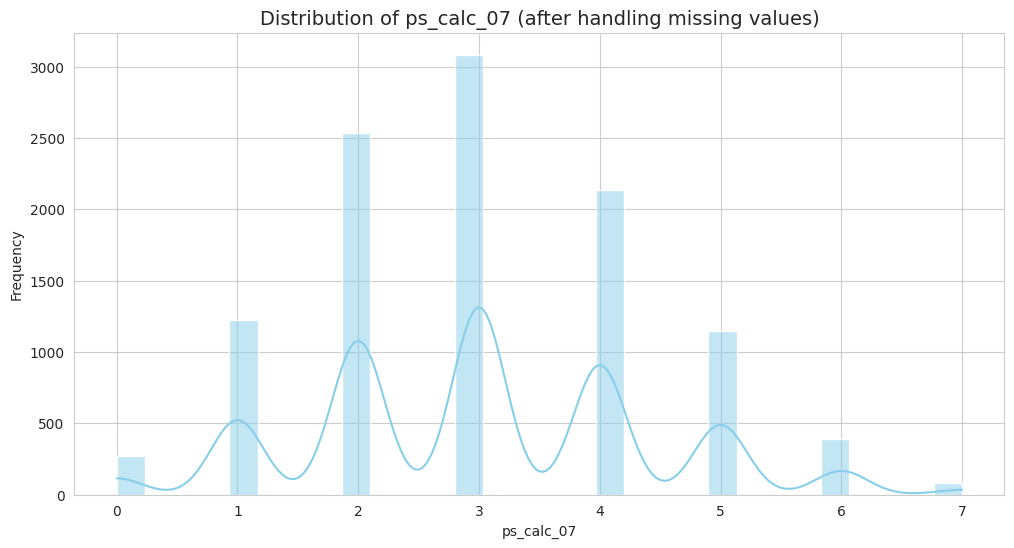

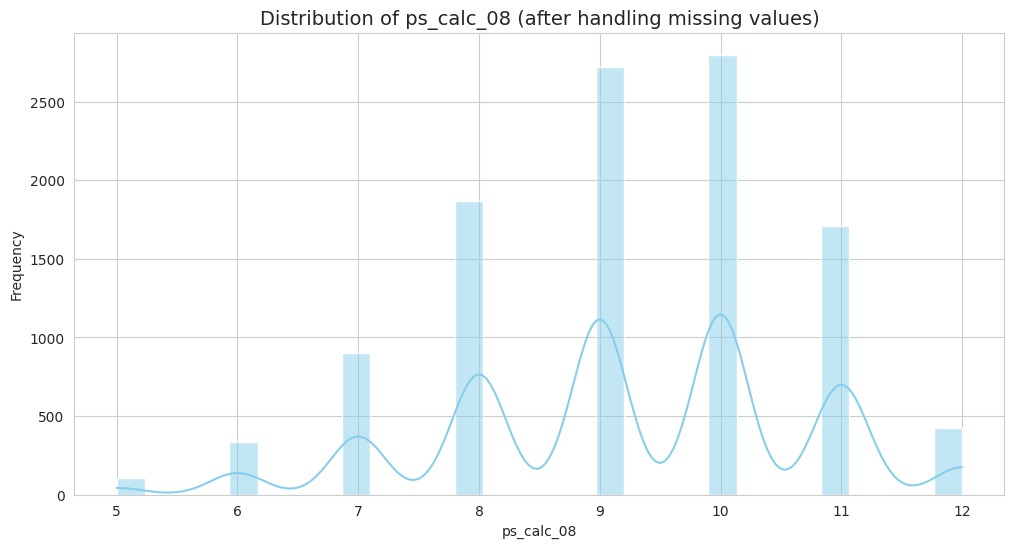

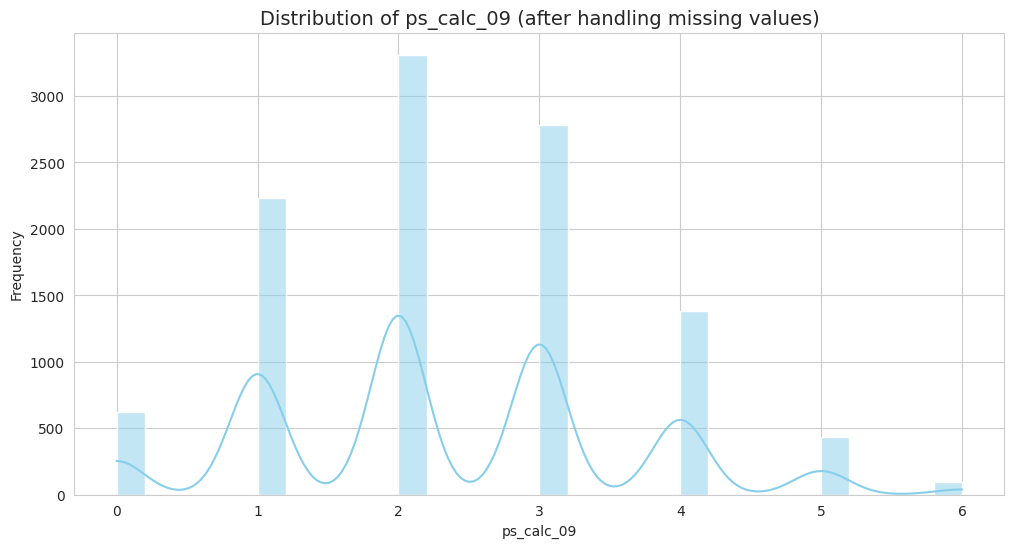

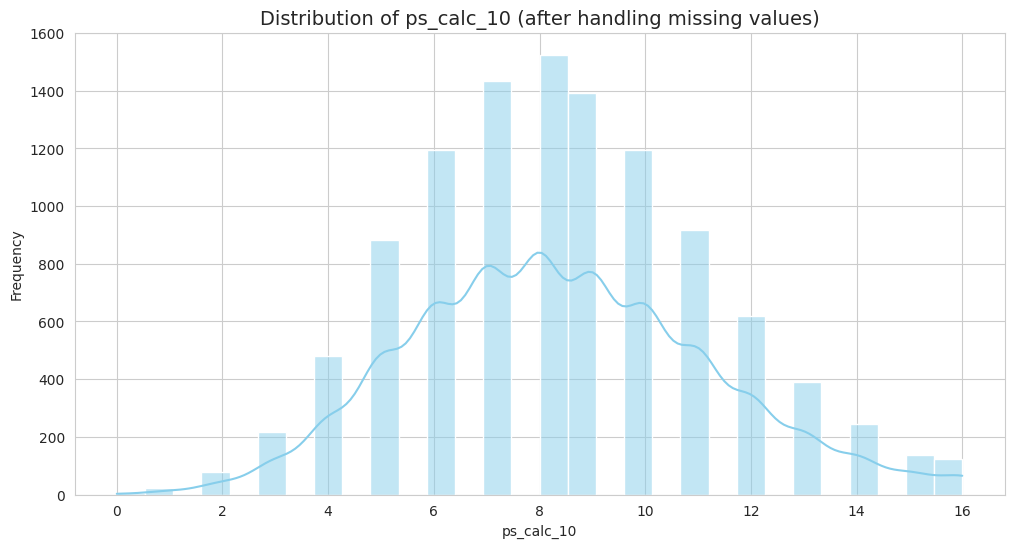

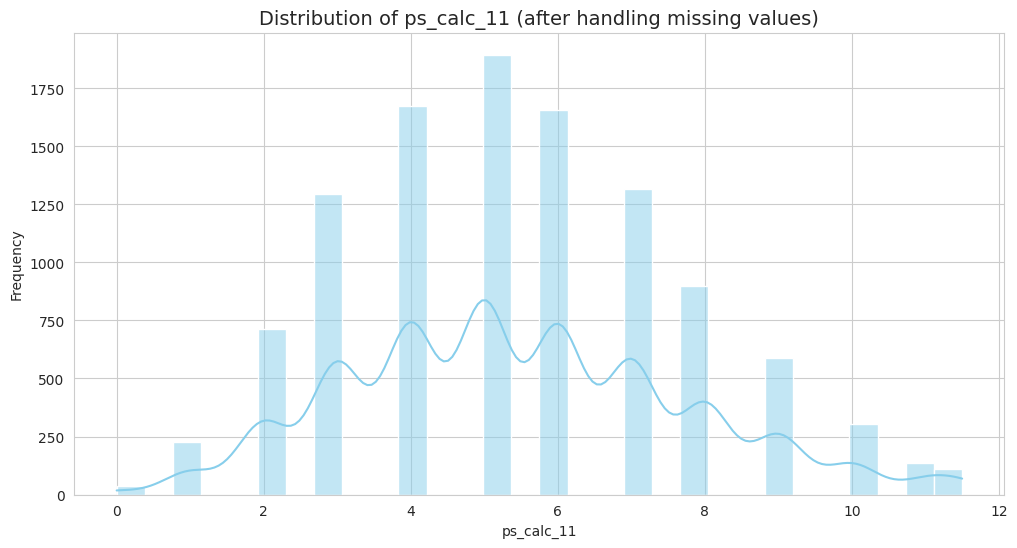

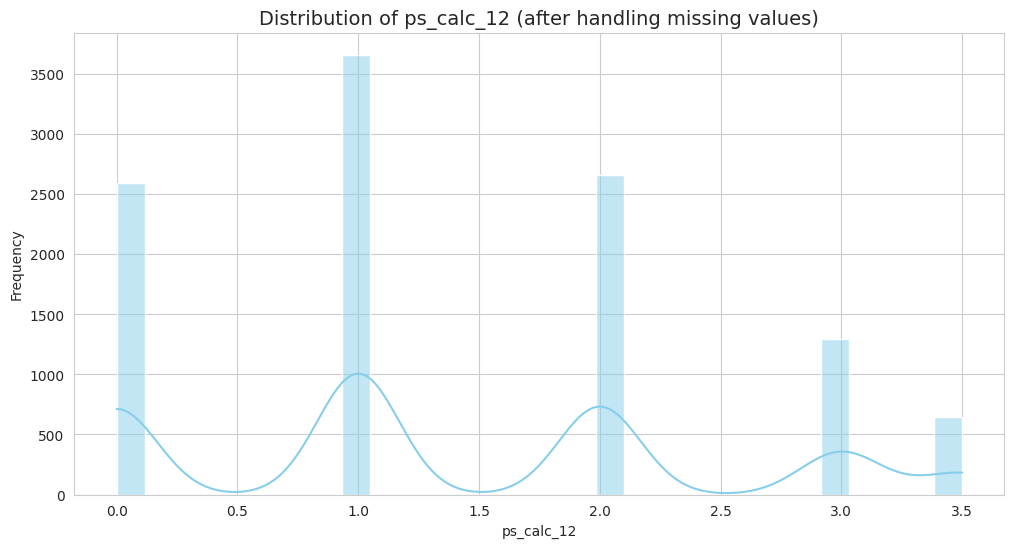

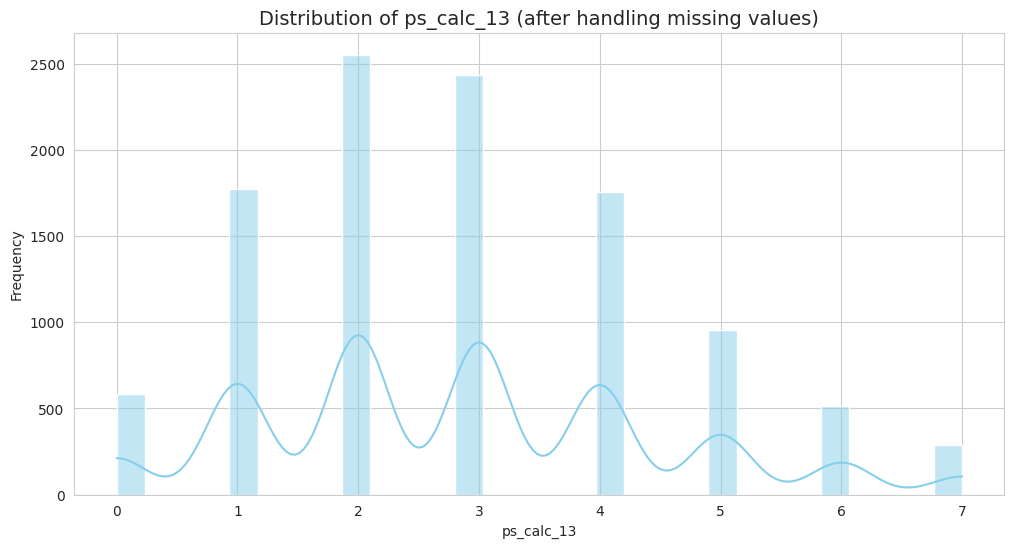

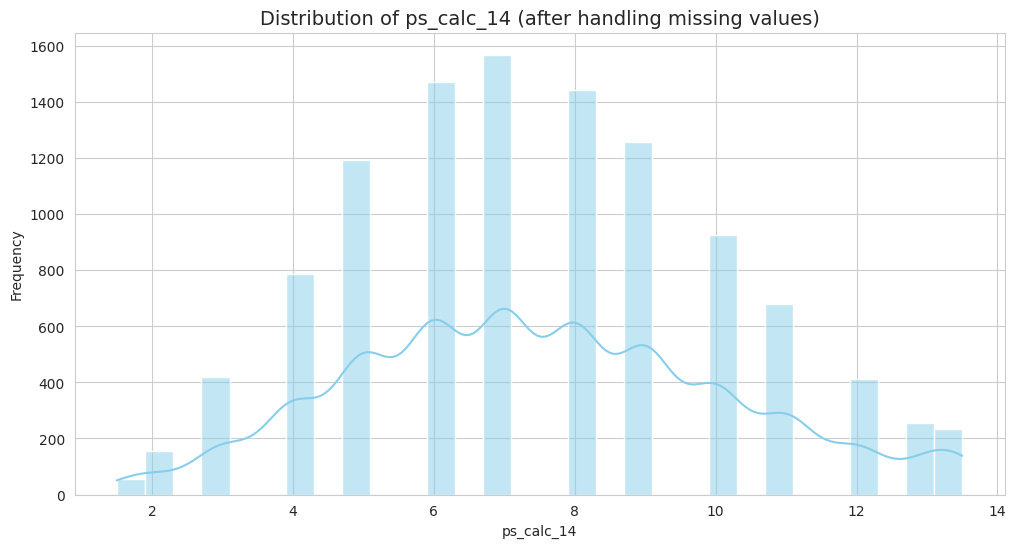

In [ ]:
for col in num_cols:
    plt.figure()
    sns.histplot(train[col], kde=True, color='skyblue', bins=30)
    plt.title(f'Distribution of {col} (after handling missing values)', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

**Feature Engineering**

In [ ]:

cat_cols = [col for col in train.columns if 'cat' in col or 'bin' in col]

for col in cat_cols:
    target_mean = train.groupby(col)['target'].mean()
    train[col] = train[col].map(target_mean)
    test[col] = test[col].map(target_mean)


In [ ]:
# Interaction features for numerical columns
num_cols = [col for col in train.columns if col not in cat_cols + ['id', 'target']]

for i in range(len(num_cols)-1):
    col1 = num_cols[i]
    col2 = num_cols[i+1]
    train[f'{col1}_x_{col2}'] = train[col1] * train[col2]
    test[f'{col1}_x_{col2}'] = test[col1] * test[col2]

In [ ]:
print("Missing values in train:")
train.isnull().sum()[train.isnull().sum() > 0]

print("\nMissing values in test:")
test.isnull().sum()[test.isnull().sum() > 0]

Missing values in train:

Missing values in test:


,0
ps_ind_02_cat,9
ps_ind_04_cat,4
ps_ind_05_cat,322
ps_car_01_cat,4
ps_car_07_cat,611
ps_car_09_cat,26
ps_car_15,1
ps_calc_01,1
ps_calc_02,1
ps_calc_03,1


In [ ]:

cat_missing_cols = ['ps_ind_02_cat', 'ps_ind_04_cat', 'ps_ind_05_cat',
                    'ps_car_01_cat', 'ps_car_02_cat', 'ps_car_07_cat', 'ps_car_09_cat']

for col in cat_missing_cols:

    mode_value = train[col].mode()[0]

    test[col].fillna(mode_value, inplace=True)


In [ ]:
test.isnull().sum()[test.isnull().sum() > 0]

,0
ps_car_15,1
ps_calc_01,1
ps_calc_02,1
ps_calc_03,1
ps_calc_04,1
ps_calc_05,1
ps_calc_06,1
ps_calc_07,1
ps_calc_08,1
ps_calc_09,1


In [ ]:

test = test.fillna(-1)


In [ ]:
test.isnull().sum()[test.isnull().sum() > 0]

,0


**Modeling**

In [ ]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
import lightgbm as lgb

X = train.drop(columns=['id', 'target'])
y = train['target']
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_val = imputer.transform(X_val)
X_test = imputer.transform(test.drop(columns=['id'], errors='ignore'))

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'LightGBM': lgb.LGBMClassifier(random_state=42)
}

param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10],
        'solver': ['liblinear', 'lbfgs']
    },
    'Random Forest': {
        'n_estimators': [100, 200, 500],
        'max_depth': [5, 10, 20, None],
        'min_samples_split': [2, 5, 10]
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200, 500],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7]
    },
    'XGBoost': {
        'n_estimators': [100, 200, 500],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7]
    },
    'LightGBM': {
        'n_estimators': [100, 200, 500],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [-1, 5, 10]
    }
}

best_models = {}
scores = {}

for name, model in models.items():
    print(f"\nTuning {name}...")
    param_grid = param_grids[name]
    search = RandomizedSearchCV(
        model,
        param_distributions=param_grid,
        n_iter=5,
        scoring='roc_auc',
        cv=3,
        verbose=1,
        n_jobs=-1,
        random_state=42
    )
    search.fit(X_train, y_train)
    best_model = search.best_estimator_
    best_models[name] = best_model

    y_pred = best_model.predict_proba(X_val)[:, 1]
    score = roc_auc_score(y_val, y_pred)
    scores[name] = score
    print(f"Best params for {name}: {search.best_params_}")
    print(f"{name} ROC-AUC after tuning: {score:.4f}")

best_model_name = max(scores, key=scores.get)
print(f"\nBest Model after tuning: {best_model_name} with ROC-AUC: {scores[best_model_name]:.4f}")

final_model = best_models[best_model_name]
test_preds = final_model.predict_proba(X_test)[:, 1]



Tuning Logistic Regression...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best params for Logistic Regression: {'solver': 'lbfgs', 'C': 10}
Logistic Regression ROC-AUC after tuning: 0.6321

Tuning Random Forest...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best params for Random Forest: {'n_estimators': 200, 'min_samples_split': 5, 'max_depth': 10}
Random Forest ROC-AUC after tuning: 0.6536

Tuning Gradient Boosting...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best params for Gradient Boosting: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01}
Gradient Boosting ROC-AUC after tuning: 0.6960

Tuning XGBoost...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best params for XGBoost: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01}
XGBoost ROC-AUC after tuning: 0.7069

Tuning LightGBM...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
[LightGBM] [Info] Number of positive: 330, number of negat

In [ ]:
X = train.drop(columns=['id', 'target'])
y = train['target']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_val = imputer.transform(X_val)
X_test = imputer.transform(test.drop(columns=['id'], errors='ignore'))


In [ ]:
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='auc'
)


In [ ]:
xgb_model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_val_pred = xgb_model.predict_proba(X_val)[:, 1]
val_score = roc_auc_score(y_val, y_val_pred)
print(f"Validation ROC-AUC: {val_score:.4f}")


Validation ROC-AUC: 0.7073


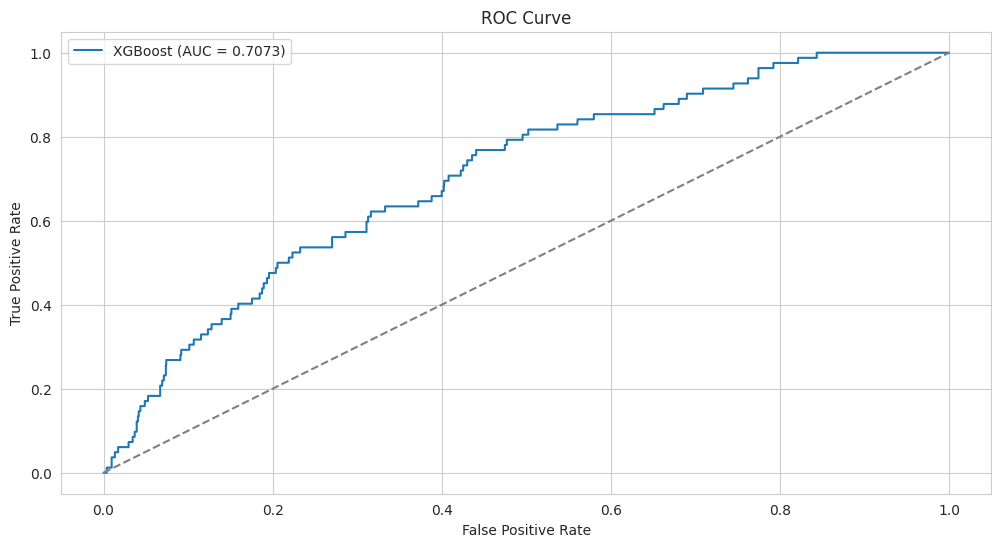

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
fpr, tpr, thresholds = roc_curve(y_val, y_val_pred)
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {val_score:.4f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [ ]:
test_preds = xgb_model.predict_proba(X_test)[:, 1]

In [ ]:
submission = pd.DataFrame({
    'id': test['id'],
    'target': test_preds
})
submission.to_csv('submission.csv', index=False)
print("submission.csv saved")

submission.csv saved
